# Phase 2: Unsupervised Learning
## Phishing URL Detection Project

This notebook presents the unsupervised learning phase for the phishing URL detection project. The goal is to apply clustering algorithms to the preprocessed dataset to uncover natural groupings within URL data and enhance the Phase 1 supervised model with cluster-based features.

## Notebook Overview

| No. | Section |
|---|---|
| 1 | Algorithm Selection & Justification |
| 2 | Data Preparation |
| 3 | Choosing k |
| 4 | Algorithm 1 — K-Means |
| 5 | Algorithm 2 — DBSCAN |
| 6 | Algorithm 3 — BIRCH  |
| 7 | Evaluation & Visualizations |
| 8 | Cluster Profiles |
| 9 | Integration Strategy |
| 10 | Challenges & Limitations |

## 1. Clustering Rationale & Algorithm Selection

### 1.1 Why Clustering on a Phishing Dataset?

Clustering is applied as an unsupervised technique to complement the supervised model developed in Phase 1. Unlike classification, clustering operates without class labels, allowing the discovery of natural groupings within the URL data that binary labels alone may not reveal. For example, phishing URLs may form distinct subgroups based on characteristics such as obfuscation level, redirect behavior, or URL length.

The resulting cluster assignments will also be used as an additional feature in the Phase 1 supervised model to improve classification performance on ambiguous or borderline URLs.

---

### 1.2 Algorithm Selection & Justification
Three clustering algorithms were selected for this study based on their suitability for the phishing URL dataset. Selection criteria included:

1. Dataset size
2. Feature type suitability
3. Expected cluster shape
4. Scalability
5. Interpretability

The dataset contains 235,795 URL records with 11 normalized numerical features, making it suitable for distance-based clustering approaches.

---

### Team Overview

| # | Algorithm | Member | Section |
|---|---|---|---|
| 1 | K-Means | *Raghad Alzakari* | 4 |
| 2 | DBSCAN | *Manar Alotaibi* | 5 |
| 3 | BIRCH  | *Roaa Alshehri* | 6 |

---

#### 1.2.1 Algorithm 1: K-Means Clustering

| Criterion | Justification for K-Means |
|---|---|
| **Dataset size** | K-Means has linear time complexity relative to dataset size, making it efficient for large datasets such as this one. |
| **Feature types** | All 11 features are numerical, consisting of continuous values representing URL structure (e.g. URLLength, DomainLength), count-based values (e.g. NoOfEqualsInURL, NoOfAmpersandInURL, NoOfObfuscatedChar), and one binary indicator (IsHTTPS). All features are normalized to [0,1], making Euclidean distance applicable across the full feature set. |
| **Expected cluster shapes** | Compact and roughly spherical clusters are expected because normalized URL features with similar structural patterns are likely to group closely in the feature space.|
| **Scalability** | K-Means converges quickly on large datasets. It is the standard baseline for tabular numerical clustering. |
| **Interpretability** | Each cluster is summarized by a centroid, which is a concrete vector of feature values that can be directly profiled and explained in domain terms. |



### 1.2.2 Algorithm 2: DBSCAN Clustering

| Criterion | Justification for DBSCAN |
|---|---|
| **Dataset size** | Although DBSCAN is more computationally expensive than centroid-based methods, the dataset’s relatively low dimensionality (11 features) makes it suitable for density-based clustering. |
| **Feature types** | All features are numerical and scaled to the range [0,1], which is ideal for DBSCAN since it relies on distance-based similarity (Euclidean distance). Proper normalization ensures that no single feature dominates the distance computation.|
| **Cluster shapes** | Arbitrary-shaped and density-based clusters are expected because phishing URL behaviors may form irregular patterns rather than compact spherical groups. |
| **Scalability** |DBSCAN is less scalable than K-Means and BIRCH due to the computational cost of neighborhood searches, but it was selected for its ability to identify complex cluster structures and noise points.|
| **Interpretability** | it can detect noise points (outliers). These can represent suspicious or unusual URLs, which is helpful for phishing detection. |

---

### 1.2.3 Algorithm 3 : BIRCH Clustering

| Criterion | Justification for BIRCH |
|---|---|
| **Dataset size** | The dataset contains 235,795 URL records with 11 features. Since the dataset is large, BIRCH is a suitable choice because it summarizes the data using a Clustering Feature (CF) Tree in a linear O(n) pass, making full-dataset clustering more practical. |
| **Feature types** | All 11 features are numerical and normalized to [0,1], making them suitable for BIRCH’s Euclidean distance-based clustering. The mix of continuous, count-based, and binary URL features can be compared fairly after normalization without requiring distributional assumptions. |
| **Expected Cluster shapes** | BIRCH produces compact, roughly spherical subclusters via its CF Tree, which is appropriate here. Phishing URL features in this dataset tend to separate along axis-aligned boundaries rather than curved or irregular ones, making spherical cluster assumptions reasonable. |
| **Scalability** | BIRCH is more memory-efficient than both K-Means and DBSCAN at this dataset size. Its CF Tree compresses the full 235,795 rows into a compact in-memory summary in a single O(n) pass, avoiding the repeated full-dataset scans required by K-Means and the neighborhood queries that forced DBSCAN to subsample to 50,000 rows. This allows BIRCH to cluster the complete dataset without subsampling. |
| **Interpretability** |Each BIRCH cluster can be summarized by its centroid vector of mean feature values, allowing each cluster to be described directly in URL domain terms. |






## 2. Data Preparation

The preprocessed dataset from Phase 1 is already cleaned, feature-selected, and scaled. This section loads the full dataset, separates the class label, and prepares the feature matrix for clustering. An alternative pipeline was explored but produced weaker results; the rationale for the final approach is documented in Section 2.3.

### 2.1 Load Data

In [1]:
# Import Google Drive module so Colab can access files stored in your Drive
from google.colab import drive

# Mount Google Drive to the Colab environment
# This allows reading/writing files from /content/drive
drive.mount('/content/drive')

import pandas as pd

# Load the full preprocessed dataset from Phase 1
df = pd.read_csv('/content/drive/MyDrive/preprocessed_PhiUSIIL_Phishing_URL_Dataset.csv')

print(f'Dataset shape: {df.shape}')
df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset shape: (235795, 12)


,URLLength,DomainLength,TLDLength,NoOfSubDomain,NoOfObfuscatedChar,NoOfEqualsInURL,NoOfQMarkInURL,NoOfAmpersandInURL,IsHTTPS,NoOfURLRedirect,NoOfSelfRedirect,label
0,0.002595,0.160377,0.090909,0.1,0.0,0.0,0.0,0.0,1.0,1.0,0.0,1
1,0.007265,0.424528,0.090909,0.2,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0
2,0.002076,0.141509,0.090909,0.2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
3,0.000865,0.066038,0.000000,0.1,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1
4,0.002595,0.160377,0.090909,0.1,0.0,0.0,0.0,0.0,1.0,1.0,0.0,1


### 2.2 Separate Label


The class label must be removed before clustering. Clustering is unsupervised which means the algorithm discovers structure from feature similarity alone, without access to ground-truth class information. Including the label would bias the groupings toward the known classification, defeating the purpose of unsupervised discovery.

The label is stored separately in `y_true` and is only used after clustering for external validation (BCubed Precision & Recall).

In [2]:
# Separate features from the class label
# The label is excluded because clustering is unsupervised, so cluster formation must not be influenced by the known class.
# y_true is stored separately for external validation only.
X = df.drop(columns=['label'])
y_true = df['label']

print(f'Features (X) : {X.shape}')
print(f'Labels  (y)  : {y_true.shape}')

# Show how many samples belong to each class
print(f'\nClass distribution:')
print(y_true.value_counts())

# Display class percentages
# Assumes label=1 means legitimate and label=0 means phishing
print(f'\nClass balance: {y_true.mean():.1%} legitimate, {1-y_true.mean():.1%} phishing')

Features (X) : (235795, 11)
Labels  (y)  : (235795,)

Class distribution:
label
1    134850
0    100945
Name: count, dtype: int64

Class balance: 57.2% legitimate, 42.8% phishing


### 2.3 Verify and Clip
The Phase 1 MinMaxScaler was fitted on the training split only, which is the correct practice for supervised learning (it prevents data leakage from the test set into the scaler's parameters). However, when all 235,795 rows (including validation and test rows) are combined for clustering, a small number of values may slightly exceed 1.0 because those rows contain feature values larger than the training-set maximum.

These overflows are minor numerical artifacts, not meaningful data. They are corrected by clipping all values to the [0,1] range. This is preferable to re-fitting a new scaler because:
- Re-fitting would shift the scaling of every feature, producing a different feature space than the one used in Phase 1, which would make the cluster labels inconsistent when appended back to the Phase 1 dataset for re-training.
- Clipping only adjusts the out-of-range tail, leaving the vast majority of values unchanged.

In [3]:
# Check for missing values and feature value range
print('Missing values:', X.isnull().sum().sum())
print(f'Min value: {X.min().min()}')
print(f'Max value: {X.max().max()}')

# Check how many values exceed 1.0
above_1 = (X > 1.0).sum().sum()
total = X.size
print(f'\nValues above 1.0: {above_1:,} out of {total:,} ({above_1/total*100:.4f}%)')


# The Phase 1 scaler was fitted on training data only (correct practice for supervised learning).
# When the full dataset is combined, a small number of values in the validation and test sets
# slightly exceed 1.0 because they contain feature values larger than the training maximum.
# Since the data is already scaled, we clip to [0, 1] to correct this minor overflow
# before computing Euclidean distances in K-Means.
X = X.clip(0, 1)

print(f'Min value after clip: {X.min().min()}')
print(f'Max value after clip: {X.max().max()}')

Missing values: 0
Min value: 0.0
Max value: 1.0666666666666669

Values above 1.0: 2 out of 2,593,745 (0.0001%)
Min value after clip: 0.0
Max value after clip: 1.0


All feature values now fall within the range [0, 1] following the clipping procedure. The class label is stored separately in `y_true` and will not be used at any point during the clustering process. It is reserved exclusively for post-hoc external validation using the BCubed metric, ensuring that the unsupervised learning phase remains unbiased by ground-truth information.

#### **Data Preparation Summary**

| Step | Action | Result |
|---|---|---|
| 2.1 | Load preprocessed dataset | 235,795 rows, 11 features + label |
| 2.2 | Separate class label | `y_true` stored separately; `X` has 11 features |
| 2.3 | Verify and clip to [0,1] | Minor overflow corrected; all values in [0,1] |

##3. K-means Clustering

### 3.1 Cluster Determination & Implementation

#### 3.1.1 Determining Optimal k

K-Means requires the number of clusters k to be specified in advance. To determine
the optimal k, two methods are used together:

- **Elbow Method:** plots the Within-Cluster Sum of Squares (WCSS) against k.
  WCSS measures how compact the clusters are. The optimal k is where the rate of
  decrease sharply slows down, forming an "elbow."

- **Silhouette Score:** measures how well each point fits its assigned cluster
  compared to other clusters. Scores range from -1 to 1, higher is better.

Both methods are used together because neither is conclusive on its own.

####3.1.1.1 Scan k=2 to 10
K-Means is run for each k from 2 to 10. `k-means++` initialization is used to place the initial centroids intelligently, which reduces the risk of poor convergence. `n_init=10` runs the algorithm 10 times and keeps the best result. The silhouette score is computed on a 5,000-point sample for speed on the 235,795-row dataset.

In [4]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

K_RANGE = range(2, 11)
wcss_values = []
silhouette_values = []

for k in K_RANGE:
    # Fit K-Means with k-means++ initialization for better convergence
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    labels = km.fit_predict(X)

    # WCSS — sum of squared distances from each point to its cluster centroid
    # Lower WCSS means more compact clusters
    wcss_values.append(km.inertia_)

    # Silhouette score — sample 5,000 points for speed on large datasets
    # Higher score means better cluster separation
    sil = silhouette_score(X, labels, sample_size=5000, random_state=42)
    silhouette_values.append(sil)

    print(f'k={k:2d}  |  WCSS={km.inertia_:,.0f}  |  Silhouette={sil:.4f}')

k= 2  |  WCSS=40,055  |  Silhouette=0.6978
k= 3  |  WCSS=15,757  |  Silhouette=0.8020
k= 4  |  WCSS=8,078  |  Silhouette=0.8356
k= 5  |  WCSS=5,282  |  Silhouette=0.8530
k= 6  |  WCSS=3,861  |  Silhouette=0.8639
k= 7  |  WCSS=3,260  |  Silhouette=0.6203
k= 8  |  WCSS=2,931  |  Silhouette=0.5229
k= 9  |  WCSS=2,604  |  Silhouette=0.4980
k=10  |  WCSS=2,380  |  Silhouette=0.5232


The table above shows WCSS decreasing as k increases, while the Silhouette Score peaks at k=6 (≈0.86). The largest WCSS drop occurs between k=2 and k=4, after which the reduction slows down. Since the Elbow Method and Silhouette Score suggest different values (k=4 and k=6 respectively), both are plotted below and a candidate comparison is performed in Section 3.1.2 to select the final k.

####3.1.1.2 Plot K

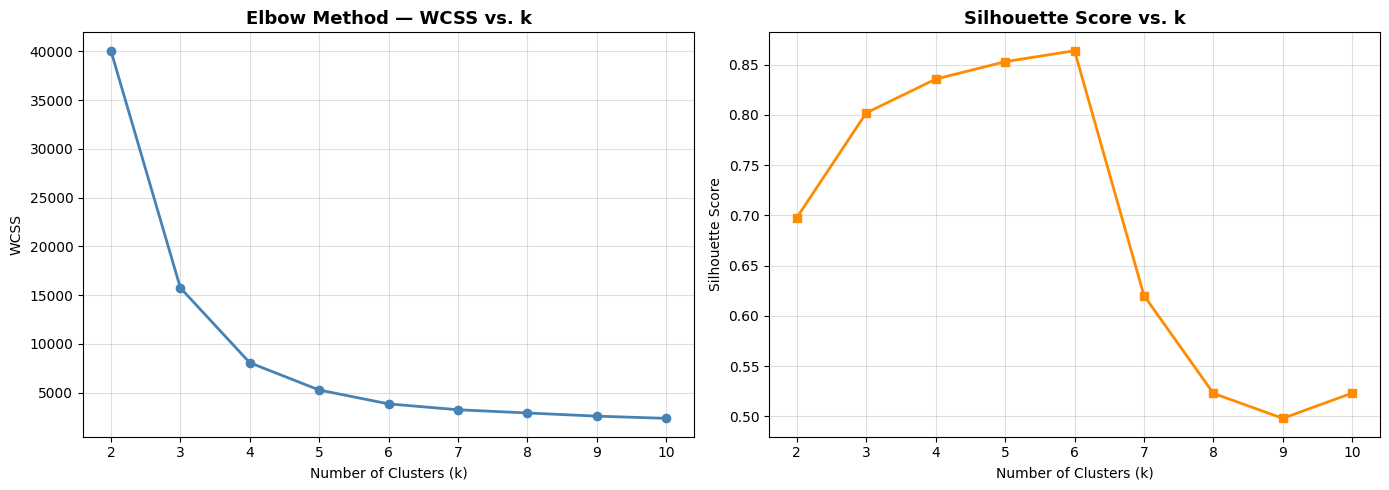

In [5]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Elbow curve
axes[0].plot(list(K_RANGE), wcss_values, marker='o', color='steelblue', linewidth=2)
axes[0].set_title('Elbow Method — WCSS vs. k', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('WCSS')
axes[0].grid(True, alpha=0.4)

# Silhouette scores
axes[1].plot(list(K_RANGE), silhouette_values, marker='s', color='darkorange', linewidth=2)
axes[1].set_title('Silhouette Score vs. k', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].grid(True, alpha=0.4)

plt.tight_layout()
plt.show()

The elbow plot shows a clear bend at k=4 where the WCSS improvement per additional cluster slows noticeably. The silhouette plot peaks at k=6 (≈0.86), with k=5 close behind. Because the two methods suggest different values, k=4, k=5, and k=6 are compared in detail below before a final selection is made.

#### 3.1.2 Candidate Comparison
The three candidate values of k are evaluated using a full set of internal metrics: WCSS, Silhouette Score, and Davies-Bouldin Index (DBI). DBI measures the average similarity between each cluster and its most similar neighbor, lower DBI values is better. Cluster profile analysis is also used to check whether the resulting clusters are domain-interpretable, not just numerically optimal.

In [6]:
from sklearn.metrics import davies_bouldin_score

candidate_ks = [4, 5, 6]

for k in candidate_ks:
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    labels = km.fit_predict(X)
    dbi = davies_bouldin_score(X, labels)
    counts = pd.Series(labels).value_counts().sort_index().tolist()

    idx = k - 2  # K_RANGE starts at 2
    print(f"k={k}")
    print(f"  WCSS            : {wcss_values[idx]:,.0f}")
    print(f"  Silhouette      : {silhouette_values[idx]:.4f}")
    print(f"  Davies-Bouldin  : {dbi:.4f}")
    print(f"  Cluster sizes   : {counts}")
    print()

k=4
  WCSS            : 8,078
  Silhouette      : 0.8356
  Davies-Bouldin  : 0.5447
  Cluster sizes   : [159765, 44566, 22007, 9457]

k=5
  WCSS            : 5,282
  Silhouette      : 0.8530
  Davies-Bouldin  : 0.4484
  Cluster sizes   : [159765, 44566, 19967, 4807, 6690]

k=6
  WCSS            : 3,861
  Silhouette      : 0.8639
  Davies-Bouldin  : 0.2231
  Cluster sizes   : [159765, 44566, 19967, 4807, 4650, 2040]



k=6 achieves the best result on all three metrics simultaneously: lowest WCSS, highest Silhouette Score, and lowest Davies-Bouldin Index. However, numerical metrics alone are not sufficient to select k, the clusters must also be domain-interpretable. The following cell examines the phishing/legitimate composition of each cluster to confirm that the groupings make semantic sense.

In [7]:
# Cluster profile analysis: examine the phishing/legitimate breakdown per cluster
# for each candidate k. This reveals whether the groupings are interpretable,
# not just numerically optimal.
for k in [4, 5, 6]:
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    labels = km.fit_predict(X)

    X_profiled = X.copy()
    X_profiled['cluster'] = labels
    X_profiled['true_label'] = y_true.values

    profile = X_profiled.groupby('cluster').agg(
        size=('true_label', 'count'),
        phishing_pct=('true_label', lambda x: (1 - x.mean()) * 100),
        **{col: (col, 'mean') for col in X.columns}
    ).round(3)

    print(f"\n{'='*20} k={k} {'='*20}")
    print(profile[['size', 'phishing_pct', 'IsHTTPS', 'NoOfURLRedirect', 'NoOfSelfRedirect', 'NoOfSubDomain', 'NoOfQMarkInURL']].to_string())


==================== k=4 ====================
           size  phishing_pct  IsHTTPS  NoOfURLRedirect  NoOfSelfRedirect  NoOfSubDomain  NoOfQMarkInURL
cluster                                                                                                 
0        159765        25.704    1.000              0.0               0.0          0.113           0.007
1         44566       100.000    0.000              0.0               0.0          0.131           0.010
2         22007        43.232    0.907              1.0               0.0          0.118           0.008
3          9457        61.320    0.508              1.0               1.0          0.109           0.008

==================== k=5 ====================
           size  phishing_pct  IsHTTPS  NoOfURLRedirect  NoOfSelfRedirect  NoOfSubDomain  NoOfQMarkInURL
cluster                                                                                                 
0        159765        25.704      1.0              0.0           

#### Interpreting the Cluster Profiles

The cluster structure is driven by three features: `IsHTTPS`, `NoOfURLRedirect`, and `NoOfSelfRedirect`. All other features show minimal variation across clusters. Since features are scaled to [0, 1], a value of `1.0` means always present in that cluster and `0.0` means never present.

**k=4: rejected.** Cluster 3 has `IsHTTPS = 0.508`, a 50/50 mix of HTTP and HTTPS URLs, and a 61% phishing rate, which is neither cleanly phishing nor legitimate. The algorithm does not have enough clusters to separate the data and is forced to merge incompatible URL types together.

**k=5: acceptable but incomplete.** The ambiguous HTTPS cluster is resolved and every cluster has a clear lean. However, Cluster 4 has `NoOfSelfRedirect = 0.695`, meaning two distinct phishing behaviors (URLs with and without self-redirects) are being merged into one cluster because k=5 does not provide enough room to separate them.

**k=6: selected.** The only structural change from k=5 is that the mixed phishing cluster (SelfRedirect=0.695) splits into two behaviorally distinct groups: phishing URLs that use both redirect types (Cluster 4) and phishing URLs that use URL redirects only (Cluster 5). This resolves the last remaining ambiguous feature value and produces six clusters where every defining feature is a clean 0 or 1, making each cluster directly interpretable as a specific URL behavior pattern:

| Cluster | IsHTTPS | URLRedirect | SelfRedirect | Identity |
|---|---|---|---|---|
| 0 | 1 | 0 | 0 | Legitimate, clean |
| 1 | 0 | 0 | 0 | Phishing, simple (no redirects, detectable by HTTPS absence alone) |
| 2 | 1 | 1 | 0 | Legitimate, single redirect |
| 3 | 1 | 1 | 1 | Legitimate, complex redirect chain |
| 4 | 0 | 1 | 1 | Phishing, aggressive (full redirect chain) |
| 5 | 0 | 1 | 0 | Phishing, URL redirect only |

This separation matters for detection: the three phishing clusters represent distinct attack behaviors, and separating legitimate redirect clusters (2 and 3) from the clean legitimate cluster (0) reduces false positives on safe URLs that happen to use redirects.

The metric comparison confirms the choice:

| Metric | k=4 | k=5 | k=6 |
|---|---|---|---|
| WCSS | 8,078 | 5,282 | **3,861** |
| Silhouette Score | 0.8356 | 0.8530 | **0.8639** |
| Davies-Bouldin Index | 0.5447 | 0.4484 | **0.2231** |

k=6 achieves the best score on all three metrics simultaneously and produces fully interpretable cluster identities, making it the optimal choice on both numerical and behavioral grounds.

#### 3.1.3 Stability Check

To confirm that the small clusters are not artifacts of random initialization,
K-Means is run across five different seeds.

In [8]:
# Stability check: run K-Means with k=6 across 5 different random seeds
# If the same cluster sizes appear consistently, the solution is stable
for seed in [0, 1, 42, 99, 123]:
    km = KMeans(n_clusters=6, init='k-means++', n_init=10, random_state=seed)
    labels = km.fit_predict(X)
    counts = sorted(pd.Series(labels).value_counts().tolist(), reverse=True)
    print(f"seed={seed}: {counts}")

seed=0: [159765, 44566, 19967, 4807, 4650, 2040]
seed=1: [159765, 44566, 19967, 4807, 4650, 2040]
seed=42: [159765, 44566, 19967, 4807, 4650, 2040]
seed=99: [159765, 44566, 19967, 4807, 4650, 2040]
seed=123: [159765, 44566, 19967, 4807, 4650, 2040]


The same six cluster sizes appear across all seeds — only the index labels change.
The small clusters (0.9% and 2.0%) are stable and reflect genuinely rare URL
patterns in the data, not initialization artifacts.

#### 3.1.3 Final K-Means Implementation

Based on the analysis above, K-Means is fitted on the full dataset with k=6.

In [9]:
OPTIMAL_K = 6

# Fit the final K-Means model on the full dataset with the selected k
# k-means++ initialization reduces the chance of suboptimal centroid placement
# n_init=10 runs 10 independent trials and keeps the best WCSS result
kmeans_final = KMeans(n_clusters=OPTIMAL_K, init='k-means++', n_init=10, random_state=42)
kmeans_labels = kmeans_final.fit_predict(X)

print(f"K-Means fitted with k={OPTIMAL_K}")
print(f"\nCluster distribution:")
cluster_counts = pd.Series(kmeans_labels).value_counts().sort_index()
for cluster, count in cluster_counts.items():
    print(f"  Cluster {cluster}: {count:,} URLs ({count/len(X)*100:.1f}%)")

K-Means fitted with k=6

Cluster distribution:
  Cluster 0: 159,765 URLs (67.8%)
  Cluster 1: 44,566 URLs (18.9%)
  Cluster 2: 19,967 URLs (8.5%)
  Cluster 3: 4,807 URLs (2.0%)
  Cluster 4: 4,650 URLs (2.0%)
  Cluster 5: 2,040 URLs (0.9%)


The model assigns all 235,795 URLs to one of six clusters. The distribution is heavily skewed, with most URLs falling into Cluster 0 (the dominant legitimate pattern) and much smaller counts in the phishing clusters. This is consistent with the class imbalance in the original dataset.

### 3.2 Evaluation Metrics & Visualizations

#### 3.2.1 Internal Evaluation Metrics
Three internal metrics are computed to quantify the quality of the K-Means solution:
- **Silhouette Score** (higher is better, range -1 to 1): measures how well each point fits its own cluster compared to neighboring clusters.
- **Davies-Bouldin Index** (lower is better): measures average similarity between
  each cluster and its most similar one, lower means better separation.
- **WCSS** (lower is better): total within-cluster sum of squares, measures compactness of clusters.

In [10]:
# Silhouette Score: sample 5,000 points for computational efficiency
sil_score = silhouette_score(X, kmeans_labels, sample_size=5000, random_state=42)

# Davies-Bouldin Index: computed on the full dataset
dbi_score = davies_bouldin_score(X, kmeans_labels)

# WCSS: stored directly in the fitted model's inertia_ attribute
wcss = kmeans_final.inertia_

print("=== K-Means Evaluation Metrics (k=6) ===")
print(f"  Silhouette Score      : {sil_score:.4f} ")
print(f"  Davies-Bouldin Index  : {dbi_score:.4f} ")
print(f"  WCSS (Inertia)        : {wcss:,.0f}")

=== K-Means Evaluation Metrics (k=6) ===
  Silhouette Score      : 0.8639 
  Davies-Bouldin Index  : 0.2231 
  WCSS (Inertia)        : 3,861


The Silhouette Score of ≈0.86 indicates strong cluster cohesion and separation. The low Davies-Bouldin Index (≈0.22) further confirms that the clusters are both compact internally and well-separated from each other. These are among the highest values observed across the k=2–10 scan, consistent with k=6 being the optimal choice.

#### 3.2.2 BCubed Precision & Recall (External Validation)

Since ground truth labels are available, BCubed Precision and Recall are computed
to externally validate how well the clusters align with the true phishing/legitimate
classes. BCubed evaluates clustering by checking, for each point, how many points
in the same cluster share the same true label.

- **BCubed Precision**: of all points in the same cluster, what fraction share the same label?
- **BCubed Recall**: of all points with the same label, what fraction are in the same cluster?

BCubed is computed on a 5,000-point sample due to its O(n²) complexity, which makes
full pairwise comparison across 235,795 rows infeasible (approximately 55 billion
operations). Sampling is the standard approach for BCubed on large datasets.

In [11]:
import numpy as np

def bcubed(labels_true, labels_pred):
    precision_scores = []
    recall_scores = []

    for i in range(len(labels_true)):
        same_cluster = labels_pred == labels_pred[i]
        same_class = labels_true == labels_true[i]

        # Precision: among points in same cluster, fraction with same label
        precision_scores.append(np.sum(same_cluster & same_class) / np.sum(same_cluster))

        # Recall: among points with same label, fraction in same cluster
        recall_scores.append(np.sum(same_cluster & same_class) / np.sum(same_class))

    bcubed_precision = np.mean(precision_scores)
    bcubed_recall = np.mean(recall_scores)
    bcubed_f1 = 2 * bcubed_precision * bcubed_recall / (bcubed_precision + bcubed_recall)
    return bcubed_precision, bcubed_recall, bcubed_f1

# Sample for speed
sample_idx = np.random.default_rng(42).choice(len(X), size=5000, replace=False)
bp, br, bf = bcubed(
    y_true.values[sample_idx],
    kmeans_labels[sample_idx]
)

print("=== BCubed External Validation ===")
print(f"  BCubed Precision : {bp:.4f}")
print(f"  BCubed Recall    : {br:.4f}")
print(f"  BCubed F1        : {bf:.4f}")
bp_km, br_km = bp, br

=== BCubed External Validation ===
  BCubed Precision : 0.7096
  BCubed Recall    : 0.5966
  BCubed F1        : 0.6482


BCubed Precision of 0.71 indicates that clusters are reasonably pure: most points in
the same cluster share the same true label. BCubed Recall of 0.60 is lower, which is
structurally expected. Cluster 0 contains a mixed population (26% phishing, 74%
legitimate), causing a portion of phishing URLs to be grouped with the legitimate
majority rather than with the pure phishing clusters. This splits the phishing class
across clusters and directly reduces recall.

Since BCubed has no established numerical thresholds, these scores are best read
alongside the primary metrics: Silhouette Score (0.8639) and Davies-Bouldin Index
(0.2231), which confirm strong cluster cohesion and separation on the full dataset.

#### 3.2.3 Visualizations

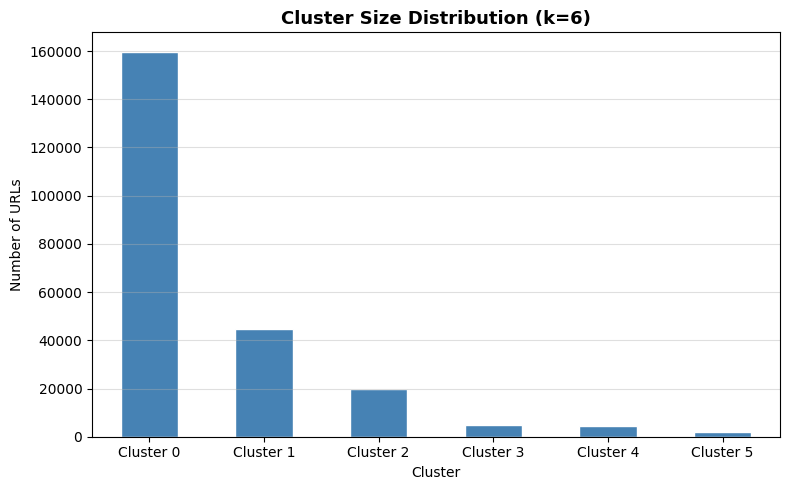

In [12]:
# --- Cluster Size Distribution ---
plt.figure(figsize=(8, 5))
cluster_counts.plot(kind='bar', color='steelblue', edgecolor='white')
plt.title(f'Cluster Size Distribution (k={OPTIMAL_K})', fontsize=13, fontweight='bold')
plt.xlabel('Cluster')
plt.ylabel('Number of URLs')
plt.xticks([i for i in range(OPTIMAL_K)],
           [f'Cluster {i}' for i in range(OPTIMAL_K)], rotation=0)
plt.grid(axis='y', alpha=0.4)
plt.tight_layout()
plt.show()

The size distribution is heavily skewed. Cluster 0 contains the majority of URLs,
reflecting the dominance of the "clean HTTPS, no redirects" pattern in the dataset.

**PCA 2D Projection**

PCA (Principal Component Analysis) reduces the 11-dimensional feature space to 2
dimensions by finding the directions of maximum variance. This allows the cluster
structure to be visualised, though it captures only a portion of the total variance.

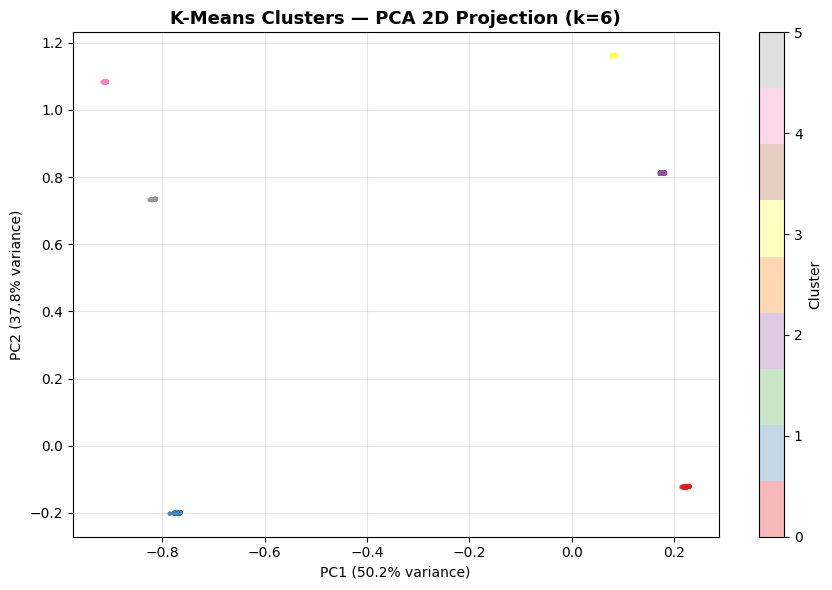

PCA explained variance: PC1=50.2%, PC2=37.8%


In [13]:
from sklearn.decomposition import PCA

# --- PCA 2D Projection ---
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X)

plt.figure(figsize=(9, 6))
scatter = plt.scatter(
    X_pca[:, 0], X_pca[:, 1],
    c=kmeans_labels,
    cmap='Set1',
    s=5,
    alpha=0.3
)
plt.title(f'K-Means Clusters — PCA 2D Projection (k={OPTIMAL_K})',
          fontsize=13, fontweight='bold')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
plt.colorbar(scatter, label='Cluster')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"PCA explained variance: PC1={pca.explained_variance_ratio_[0]*100:.1f}%, "
      f"PC2={pca.explained_variance_ratio_[1]*100:.1f}%")

The PCA projection shows clearly separated cluster regions in the reduced 2D space.
Phishing clusters form distinct bands separated from the legitimate clusters, consistent
with the high Silhouette Score. Note that PCA is a linear projection and captures only
a portion of the total variance in the 11-dimensional space; clusters that appear close
in this plot may still be well-separated in the full feature space. The quantitative
metrics (Silhouette Score, DBI) take precedence over this visual.

**Feature Importance per Cluster (Heatmap)**

The heatmap shows the mean value of each feature within each cluster. It reveals which
features drive the cluster structure and what each cluster's "personality" is in domain
terms.

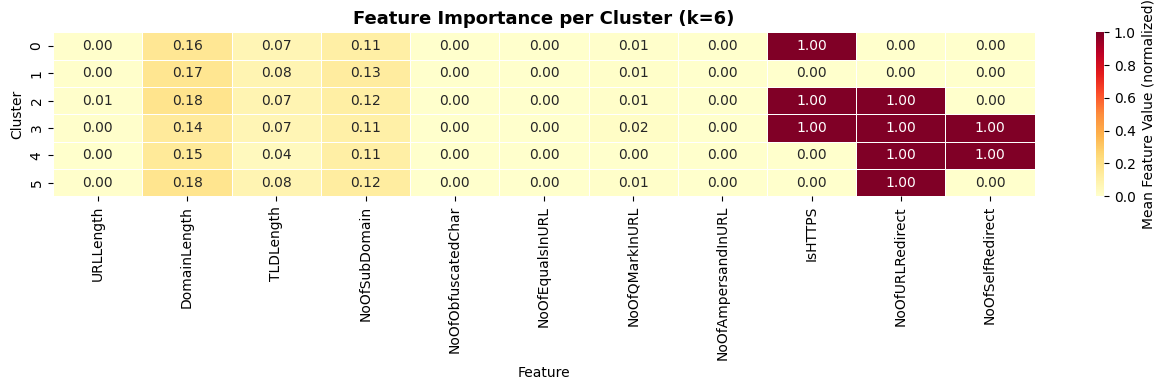

In [14]:
import seaborn as sns

# --- Feature Importance per Cluster (Heatmap) ---
X_with_labels = X.copy()
X_with_labels['cluster'] = kmeans_labels

cluster_profiles = X_with_labels.groupby('cluster')[X.columns.tolist()].mean().round(3)

plt.figure(figsize=(13, 4))
sns.heatmap(
    cluster_profiles,
    annot=True,
    fmt='.2f',
    cmap='YlOrRd',
    linewidths=0.5,
    cbar_kws={'label': 'Mean Feature Value (normalized)'}
)
plt.title(f'Feature Importance per Cluster (k={OPTIMAL_K})',
          fontsize=13, fontweight='bold')
plt.xlabel('Feature')
plt.ylabel('Cluster')
plt.tight_layout()
plt.show()

The heatmap makes the cluster structure immediately interpretable. `IsHTTPS` exhibits
the most pronounced contrast across clusters: phishing clusters display a mean value
of 0.00, while legitimate clusters display a mean value of 1.00, confirming that the
absence of HTTPS encryption is the single most discriminative structural feature in
this dataset. `NoOfURLRedirect` and `NoOfSelfRedirect` act as secondary separators,
differentiating redirect-based subgroups within both the phishing and legitimate
classes. Most remaining features (`URLLength`, `TLDLength`, `NoOfEqualsInURL`,
`NoOfQMarkInURL`, `NoOfAmpersandInURL`, `NoOfObfuscatedChar`) register near 0.00
across all six clusters, indicating that they do not contribute meaningful
discriminating signal to the cluster structure.

#### t-SNE 2D Projection

t-SNE (t-Distributed Stochastic Neighbor Embedding) is a non-linear dimensionality reduction technique that better preserves local structure than PCA. Points that are close together in the high-dimensional feature space tend to remain close in the 2D t-SNE projection. It is used here as a complementary visualization to the PCA plot.A 50,000-point sample is used because t-SNE has O(n²) computational complexity,
making it computationally expensive to run on the full 235,795-row dataset with
little added benefit. A larger sample than BCubed and Silhouette (5,000 points) is used here because t-SNE is a visual tool meaning more points produce a denser and more representative projection of the cluster structure.

/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


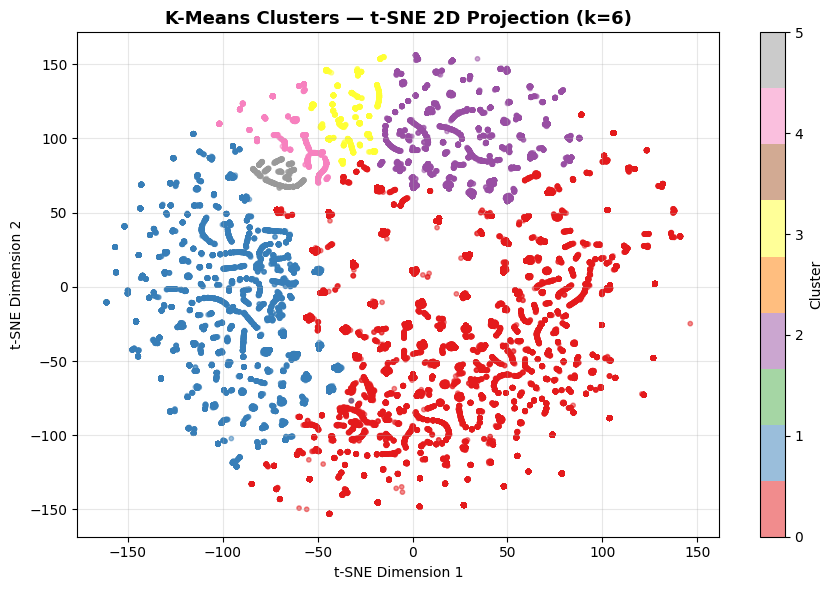

In [15]:
from sklearn.manifold import TSNE

# Sample 10,000 points — t-SNE is O(n²) and too slow on the full dataset
tsne_idx = np.random.default_rng(42).choice(len(X), size=50000, replace=False)
X_tsne_sample   = X.values[tsne_idx]
labels_tsne      = kmeans_labels[tsne_idx]

# Fit t-SNE — perplexity controls the balance between local and global structure
# 30 is the standard default; n_iter=1000 ensures convergence
tsne = TSNE(n_components=2, perplexity=30, n_iter=1000, random_state=42)
X_tsne = tsne.fit_transform(X_tsne_sample)

plt.figure(figsize=(9, 6))
scatter = plt.scatter(
    X_tsne[:, 0], X_tsne[:, 1],
    c=labels_tsne,
    cmap='Set1',
    s=10,
    alpha=0.5
)
plt.title(f'K-Means Clusters — t-SNE 2D Projection (k={OPTIMAL_K})',
          fontsize=13, fontweight='bold')
plt.xlabel('t-SNE Dimension 1')
plt.ylabel('t-SNE Dimension 2')
plt.colorbar(scatter, label='Cluster')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

The t-SNE projection reveals a more complex cluster structure than the PCA plot
suggested. Cluster 0 (red), the largest cluster, is highly fragmented across the
projection space rather than forming a compact region, indicating that it groups
together URLs with diverse local structures under a single centroid. This is a known
limitation of K-Means: it minimizes global WCSS and can merge locally distinct
subgroups when they share a similar centroid position. The smaller clusters (1, 3,
4, 5) appear as compact isolated islands in the upper region of the plot, confirming
their internal homogeneity. Cluster 2 (blue) forms a dense but broader region on the
left, suggesting URLs that vary along one dominant structural dimension. Note that
distances between clusters in the t-SNE plot are not directly interpretable — only
local grouping patterns carry meaning. The high Silhouette Score (0.8639) reflects
global separation between centroids, not necessarily tight local cohesion within
each cluster.

###3.3 Cluster Interpretation & Profiles

#### Cluster Interpretation

Each cluster has a distinct and interpretable identity based on HTTPS usage,
redirect behavior, and phishing composition:

| Cluster | Size | Phishing% | Identity | Key Characteristics |
|---|---|---|---|---|
| 0 | 159,765 | 25.7% | Legitimate-leaning | HTTPS=1, no redirects |
| 1 | 44,566 | 100% | Pure phishing | HTTPS=0, no redirects |
| 2 | 19,967 | 37.4% | Legitimate-leaning | HTTPS=1, URL redirect only |
| 3 | 4,807 | 23.9% | Legitimate-leaning | HTTPS=1, both redirects |
| 4 | 4,650 | 100% | Pure phishing | HTTPS=0, both redirects |
| 5 | 2,040 | 100% | Pure phishing | HTTPS=0, URL redirect only |

**Key findings:**

- The primary separator across all clusters is `IsHTTPS`: every phishing cluster
  has HTTPS=0 while every legitimate-leaning cluster has HTTPS=1, confirming that
  the absence of encryption is the strongest structural signal of phishing in this
  dataset.

- Redirect behavior (`NoOfURLRedirect`, `NoOfSelfRedirect`) further subdivides
  both phishing and legitimate groups into more specific URL patterns, capturing
  meaningful behavioral differences within each class.

- Most remaining features register near 0.00 across all clusters, indicating that
  they do not contribute meaningful discriminating signal to the cluster structure.

- K-Means successfully captured domain-relevant groupings purely from lexical URL
  features, without access to class labels during clustering.

##4.DBSCAN

### 4.1 Cluster Determination & Implementation

DBSCAN (Density-Based Spatial Clustering of Applications with Noise) is an unsupervised clustering algorithm that groups data points based on density rather than predefined cluster counts. Unlike methods such as K-Means, DBSCAN does not require specifying the number of clusters in advance.

It relies on two key parameters:


*   eps (ε): Defines the neighborhood radius around a point.

*   min_samples: Minimum number of points required to form a dense region (cluster).


Points that do not belong to any dense region are labeled as noise (-1).

#### 4.1.1 Data Sampling

DBSCAN has O(n²) time complexity due to pairwise neighborhood queries. Running it on
the full 235,795-row dataset caused excessive runtime and memory usage in the Colab
environment. A random sample of 50,000 rows is used instead. This preserves the
overall structure of the dataset while making computation feasible.


In [16]:
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score, davies_bouldin_score
import pandas as pd
import numpy as np

# Random sampling
X_sample = X.sample(n=50000, random_state=42)

print("Sample shape:", X_sample.shape)

Sample shape: (50000, 11)


#### 4.1.2 Selecting eps: k-Distance Plot

The k-distance plot is the standard method for selecting eps in DBSCAN. For each
point, the distance to its k-th nearest neighbor is computed and sorted in descending
order. The optimal eps corresponds to the elbow of the curve, where the distance
begins to increase sharply. Points to the left of the elbow are core points; points
to the right are likely noise.

k is set equal to min_samples (20), which is the standard convention.

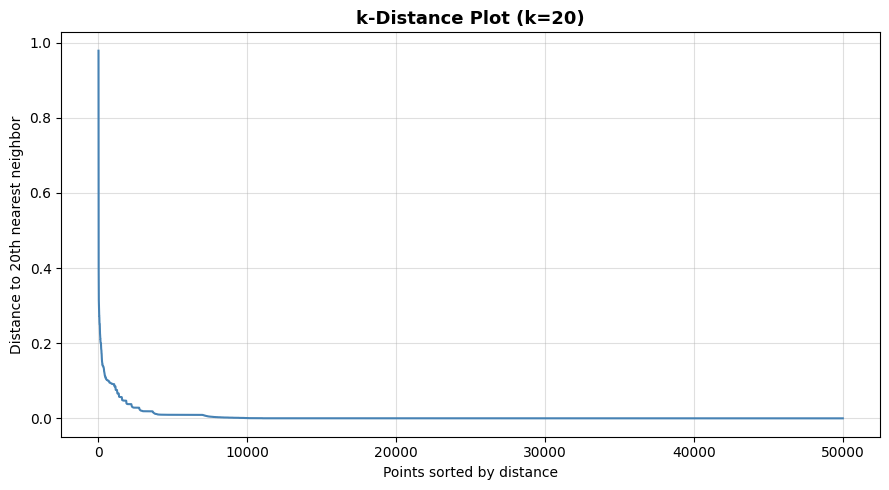

In [17]:
from sklearn.neighbors import NearestNeighbors
import matplotlib.pyplot as plt

k = 20
nbrs = NearestNeighbors(n_neighbors=k).fit(X_sample)
distances, _ = nbrs.kneighbors(X_sample)

k_distances = np.sort(distances[:, -1])[::-1]

plt.figure(figsize=(9, 5))
plt.plot(k_distances, color='steelblue', linewidth=1.5)
plt.title('k-Distance Plot (k=20)', fontsize=13, fontweight='bold')
plt.xlabel('Points sorted by distance')
plt.ylabel('Distance to 20th nearest neighbor')
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

The k-distance plot shows a steep initial drop from nearly 1.0 to around 0.1 within
the first 1,000 points, followed by a gradual decay that reaches near 0 by
approximately 5,000 points. The remaining 90% of points have a distance of essentially
0 to their 20th nearest neighbor. There is no distinct elbow, which confirms that the
dataset lacks the density variation DBSCAN relies on. The very small distances for the
majority of points reflect the binary nature of the dominant features, causing most
URLs to occupy the same discrete coordinates in the feature space. The small number of
points with distances above 0.1 represent structurally unusual URLs that are far from
any dense region.

#### 4.1.3 Parameter Tuning: Grid Search

A range of values for eps and min_samples were tested to identify a suitable
configuration.

In [18]:
# Define parameter ranges for DBSCAN
# eps controls neighborhood radius
# min_samples defines minimum points to form a cluster

eps_values = [0.02, 0.03, 0.05, 0.07, 0.1]
min_samples_values = [5, 10, 20]

results = []

# Try all combinations
for eps in eps_values:
    for min_samples in min_samples_values:

        # Apply DBSCAN with current parameters
        dbscan = DBSCAN(eps=eps, min_samples=min_samples)
        labels = dbscan.fit_predict(X_sample)

        # Count clusters (excluding noise = -1)
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)

        # Calculate noise ratio
        noise_ratio = np.mean(labels == -1)

        # Only calculate metrics if more than 1 cluster exists
        if n_clusters > 1:
            sil = silhouette_score(X_sample, labels)
            dbi = davies_bouldin_score(X_sample, labels)
        else:
            sil = -1
            dbi = np.inf

        # Store results
        results.append({
            "eps": eps,
            "min_samples": min_samples,
            "n_clusters": n_clusters,
            "noise_ratio": noise_ratio,
            "silhouette_score": sil,
            "davies_bouldin_index": dbi
        })


,eps,min_samples,n_clusters,noise_ratio,silhouette_score,davies_bouldin_index
14,0.10,20,21,0.00834,0.561076,1.106395
12,0.10,5,36,0.00306,0.560765,1.161218
13,0.10,10,31,0.00422,0.560213,1.135841
6,0.05,5,132,0.00748,0.446713,1.120058
9,0.07,5,130,0.00626,0.443486,1.139193
10,0.07,10,96,0.01162,0.442909,1.116654
7,0.05,10,96,0.01348,0.441191,1.091902
3,0.03,5,136,0.01104,0.441142,1.073641
11,0.07,20,77,0.01836,0.434579,1.112031
4,0.03,10,94,0.01962,0.433770,1.065689


**Results Analysis**

The results are sorted based on the silhouette score (higher is better) and Davies-Bouldin index (lower is better).

In [19]:
# Convert results to DataFrame
results_df = pd.DataFrame(results)

# Sort by best clustering quality
results_df.sort_values(
    by=["silhouette_score", "davies_bouldin_index"],
    ascending=[False, True]
)

,eps,min_samples,n_clusters,noise_ratio,silhouette_score,davies_bouldin_index
14,0.10,20,21,0.00834,0.561076,1.106395
12,0.10,5,36,0.00306,0.560765,1.161218
13,0.10,10,31,0.00422,0.560213,1.135841
6,0.05,5,132,0.00748,0.446713,1.120058
9,0.07,5,130,0.00626,0.443486,1.139193
10,0.07,10,96,0.01162,0.442909,1.116654
7,0.05,10,96,0.01348,0.441191,1.091902
3,0.03,5,136,0.01104,0.441142,1.073641
11,0.07,20,77,0.01836,0.434579,1.112031
4,0.03,10,94,0.01962,0.433770,1.065689


The initial results showed that:

Lower eps values produced too many clusters (over-fragmentation).
Although silhouette scores were reasonable, the clustering was not interpretable due to excessive cluster counts.

#### 4.1.4 Parameter Refinement

To reduce the number of clusters and improve interpretability, additional experiments were conducted with larger values of eps.
In this refinement step, min_samples was fixed at 20 based on earlier results, as it reduced over-fragmentation and produced more stable clusters. Therefore, only eps values were further explored (0.12, 0.13, 0.14, 0.15) to identify the optimal neighborhood radius.

**NOTE:** Lower eps values and smaller min_samples were tested,
but resulted in excessive runtime or memory instability in Google Colab.
The selected parameters (eps=0.15, min_samples=20) provide a stable balance
between clustering quality and computational feasibility.

In [20]:
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score, davies_bouldin_score
import pandas as pd
import numpy as np

eps_values_refined = [0.12, 0.13, 0.14, 0.15]

results_refined = []

for eps in eps_values_refined:

    dbscan = DBSCAN(eps=eps, min_samples=20)
    labels = dbscan.fit_predict(X_sample)

    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    noise_ratio = np.mean(labels == -1)

    mask = labels != -1

    sil = silhouette_score(X_sample[mask], labels[mask])
    dbi = davies_bouldin_score(X_sample[mask], labels[mask])

    results_refined.append({
        "eps": eps,
        "clusters": n_clusters,
        "noise": noise_ratio,
        "silhouette": sil,
        "DBI": dbi
    })

pd.DataFrame(results_refined)

,eps,clusters,noise,silhouette,DBI
0,0.12,15,0.00412,0.596023,0.577884
1,0.13,13,0.00390,0.594301,0.602847
2,0.14,12,0.00360,0.601076,0.642669
3,0.15,12,0.00302,0.615220,0.716370


The refinement results indicate that increasing the eps value reduces the number of clusters while improving cluster cohesion. Although` eps = 0.12` achieved a lower Davies-Bouldin Index, `eps = 0.15` was selected as the optimal configuration because it produced fewer and more interpretable clusters, while achieving the highest silhouette score and maintaining a very low noise ratio.

#### 4.1.5 Final DBSCAN Model

Based on the evaluation results, the best parameter combination which is `eps = 0.15` and ` min_samples = 20 `is selected for the final DBSCAN model.

In [21]:
# Build the final DBSCAN model using the selected parameters
# eps = 0.15 was selected because it achieved the highest silhouette score
# and produced fewer, more interpretable clusters
# min_samples = 20 was used to reduce over-fragmentation

dbscan_final = DBSCAN(eps=0.15, min_samples=20)

# Fit the final model on the sampled data
dbscan_labels = dbscan_final.fit_predict(X_sample)

# Show cluster distribution
cluster_counts = pd.Series(dbscan_labels).value_counts().sort_index()

print("Cluster counts:")
print(cluster_counts)

# Show noise percentage clearly
noise_percentage = (dbscan_labels == -1).mean() * 100
print(f"\nNoise percentage: {noise_percentage:.2f}%")

Cluster counts:
-1       151
 0     33149
 1       951
 2      4059
 3      9175
 4       430
 5       661
 6       263
 7       915
 8        49
 9        64
 10      112
 11       21
Name: count, dtype: int64

Noise percentage: 0.30%


In DBSCAN, the label `-1` represents noise points, meaning observations that do not belong to any dense cluster.

The final DBSCAN model produced a few large clusters and several smaller ones, suggesting that some URL patterns are common while others are more specific and less frequent. The noise ratio is very low (about 0.30%), indicating that most sampled URLs were successfully assigned to clusters.

###4.2 Evaluation Metrics & Visualizations

In this section, the performance of the selected DBSCAN model is evaluated using clustering quality metrics and visualizations. Since DBSCAN is an unsupervised algorithm, both internal evaluation metrics (e.g., Silhouette Score, Davies-Bouldin Index) and external metrics (e.g., BCubed Precision and Recall) are used to assess clustering quality.

The following metrics are considered:

*   Silhouette Score (higher is better): measures how well-separated the clusters
*   Davies-Bouldin Index (lower is better): measures cluster compactness and separation.
*   Noise Ratio: percentage of points classified as noise (-1).
*   BCubed Precision and Recall: external metrics used to compare cluster assignments with the true labels.
*   WCSS: not used for DBSCAN because DBSCAN is density-based and does not rely on centroids.

Visualizations are also used to better understand the distribution and structure of the clusters.

#### 4.2.1 Internal Evaluation Metrics

In [22]:
from sklearn.metrics import silhouette_score, davies_bouldin_score

# Count clusters excluding noise
n_clusters = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)

# Noise percentage
noise_percentage = (dbscan_labels == -1).mean() * 100

# Exclude noise points for internal metrics
mask = dbscan_labels != -1

if n_clusters > 1:
    sil = silhouette_score(X_sample[mask], dbscan_labels[mask])
    dbi = davies_bouldin_score(X_sample[mask], dbscan_labels[mask])
else:
    sil = -1
    dbi = float('inf')

print("Number of clusters:", n_clusters)
print(f"Noise percentage: {noise_percentage:.2f}%")
print(f"Silhouette Score: {sil:.4f}")
print(f"Davies-Bouldin Index: {dbi:.4f}")

Number of clusters: 12
Noise percentage: 0.30%
Silhouette Score: 0.6152
Davies-Bouldin Index: 0.7164


The final DBSCAN model produced 12 clusters with a very low noise percentage of 0.30%.
The Silhouette Score of 0.6152 indicates reasonably strong clustering structure., while the
Davies-Bouldin Index of 0.7164 is notably higher than K-Means (0.2231) and BIRCH
(0.2819), indicating weaker cluster compactness and separation. This is consistent
with the dataset not being well-suited for density-based clustering, as confirmed by
the k-distance plot.

**Within-Cluster Sum Of Sqaures explaination**

WCSS (Within-Cluster Sum of Squares) is commonly used for centroid-based clustering algorithms such as K-Means. However, it is not applicable in this case because DBSCAN is a density-based algorithm that does not rely on centroids and can identify clusters of arbitrary shapes. Therefore, WCSS is not a suitable evaluation metric for DBSCAN.

#### 4.2.2 BCubed Precision & Recall (External Validation)

BCubed Precision and Recall are external evaluation metrics used to assess how well clustering results align with the true class labels. Unlike internal metrics such as Silhouette Score, BCubed considers ground truth labels and evaluates cluster purity and completeness.

BCubed Precision measures how many data points within the same cluster share the same true label, while BCubed Recall measures how well all instances of the same true label are grouped together.

In [53]:
import numpy as np
import pandas as pd

# Get true labels for the same sampled rows
y_sample = y_true.loc[X_sample.index]

# Exclude DBSCAN noise points
mask = dbscan_labels != -1

y_eval = np.array(y_sample[mask])
cluster_eval = np.array(dbscan_labels[mask])

# BCubed Precision and Recall
bcubed_precision_scores = []
bcubed_recall_scores = []

for i in range(len(y_eval)):
    same_cluster = cluster_eval == cluster_eval[i]
    same_label = y_eval == y_eval[i]

    precision_i = np.sum(same_cluster & same_label) / np.sum(same_cluster)
    recall_i = np.sum(same_cluster & same_label) / np.sum(same_label)

    bcubed_precision_scores.append(precision_i)
    bcubed_recall_scores.append(recall_i)

bcubed_precision = np.mean(bcubed_precision_scores)
bcubed_recall = np.mean(bcubed_recall_scores)

print(f"BCubed Precision: {bcubed_precision:.4f}")
print(f"BCubed Recall: {bcubed_recall:.4f}")
bp_db = bcubed_precision
br_db = bcubed_recall

BCubed Precision: 0.7154
BCubed Recall: 0.5935


The obtained BCubed Precision score of `0.7154` indicates that most data points grouped within the same cluster tend to share the same true label, suggesting good cluster purity.

The BCubed Recall score of `0.5935` indicates that instances belonging to the same true class are somewhat distributed across multiple clusters, meaning that DBSCAN splits some classes into several smaller clusters.

Overall, these results suggest that DBSCAN successfully captures meaningful patterns related to the data labels, while still producing multiple sub-clusters for the same class due to its sensitivity to local density variations.

#### 4.2.3 Cluster Size Distribution

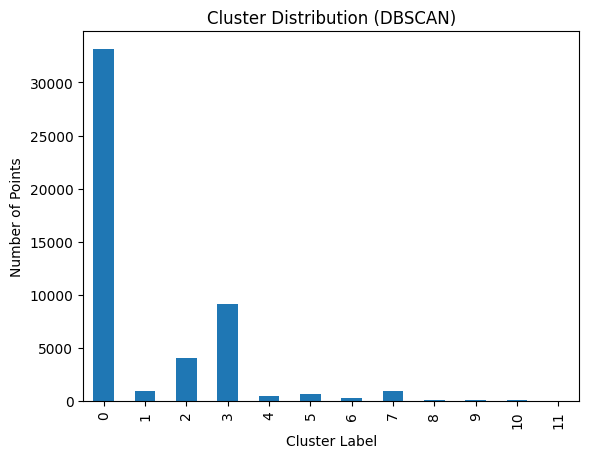

In [24]:
import matplotlib.pyplot as plt

# Count cluster sizes excluding noise from the plot
cluster_counts = pd.Series(dbscan_labels[dbscan_labels != -1]).value_counts().sort_index()

plt.figure()
cluster_counts.plot(kind='bar')
plt.title("Cluster Distribution (DBSCAN)")
plt.xlabel("Cluster Label")
plt.ylabel("Number of Points")
plt.show()

The cluster distribution shows that most data points are concentrated in a few large clusters, while several smaller clusters also exist. This suggests that certain URL patterns are more common, while others represent more specific or rare behaviors. Noise points (excluded from the visualization) account for only a small proportion of the dataset, confirming that most observations were successfully grouped into meaningful clusters.

#### 4.2.4 PCA 2D Projection

PCA reduces the 11-dimensional feature space to 2 dimensions to allow visual
inspection of the cluster structure. Noise points are excluded from the projection.

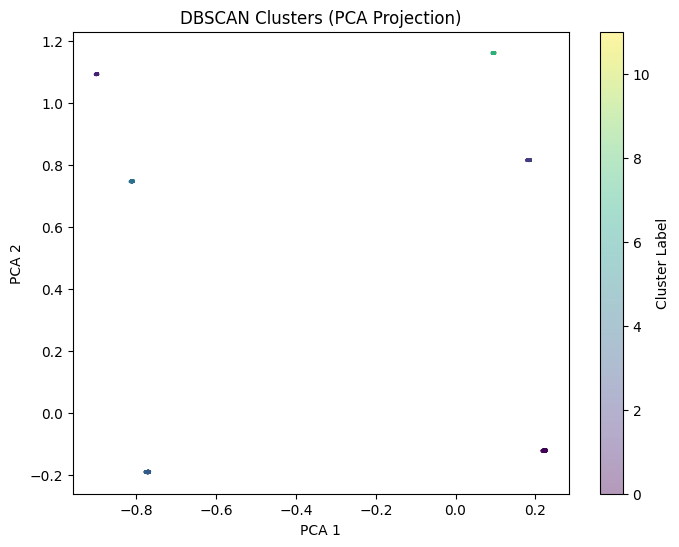

In [26]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import pandas as pd

# Use full dataset (DO NOT remove duplicates)
X_vis = X_sample
labels_vis = pd.Series(dbscan_labels, index=X_sample.index)

# Remove only noise (-1)
mask = labels_vis != -1
X_clean = X_vis[mask]
labels_clean = labels_vis[mask]

# Apply PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_clean)

# Plot
plt.figure(figsize=(8,6))

scatter = plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=labels_clean,
    s=2,        # small points for large dataset
    alpha=0.4
)

plt.title("DBSCAN Clusters (PCA Projection)")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.colorbar(scatter, label="Cluster Label")

plt.show()

The PCA visualization shows the DBSCAN clustering results in two dimensions. Many observations overlap in the same PCA positions because the dataset contains repeated or very similar URL feature patterns. Therefore, the plot appears as a small number of dense points rather than widely spread clusters. Despite this limitation, the visualization supports the presence of distinct structural groups, while the quantitative metrics provide a more reliable evaluation of clustering quality.

#### 4.2.5 t-SNE 2D Projection

t-SNE was used to visualize the DBSCAN clusters in two dimensions. It helps show local relationships between data points more clearly than PCA. A smaller sample was used to reduce computation time, and noise points were excluded to focus on the main cluster structure. This visualization supports the quantitative evaluation results.

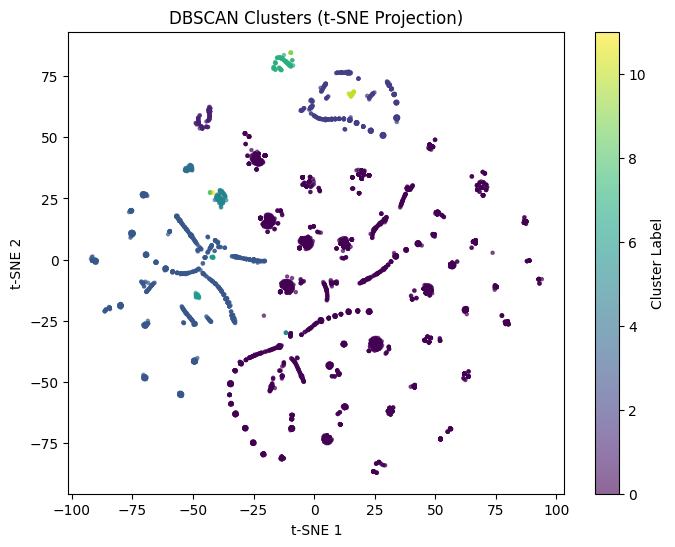

In [27]:
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import pandas as pd

# Use a smaller subset for speed
X_vis = X_sample.sample(n=5000, random_state=42)
labels_vis = pd.Series(dbscan_labels, index=X_sample.index).loc[X_vis.index]

# Remove noise
mask = labels_vis != -1
X_clean = X_vis[mask]
labels_clean = labels_vis[mask]

# Apply t-SNE
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_tsne = tsne.fit_transform(X_clean)

# Plot
plt.figure(figsize=(8,6))

scatter = plt.scatter(
    X_tsne[:, 0],
    X_tsne[:, 1],
    c=labels_clean,
    s=5,
    alpha=0.6
)

plt.title("DBSCAN Clusters (t-SNE Projection)")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.colorbar(scatter, label="Cluster Label")

plt.show()

The t-SNE visualization reveals multiple well-separated clusters, indicating that DBSCAN successfully identified meaningful groupings in the data. Some clusters are dense and compact, while others are more dispersed, reflecting variability in data patterns. Smaller clusters and scattered points suggest less frequent or more specific behaviors within the dataset.

#### 4.2.6 Feature Importance per Cluster (Heatmap)

The heatmap shows the mean value of each feature within each DBSCAN cluster,
excluding noise points. It reveals which features drive the cluster structure.

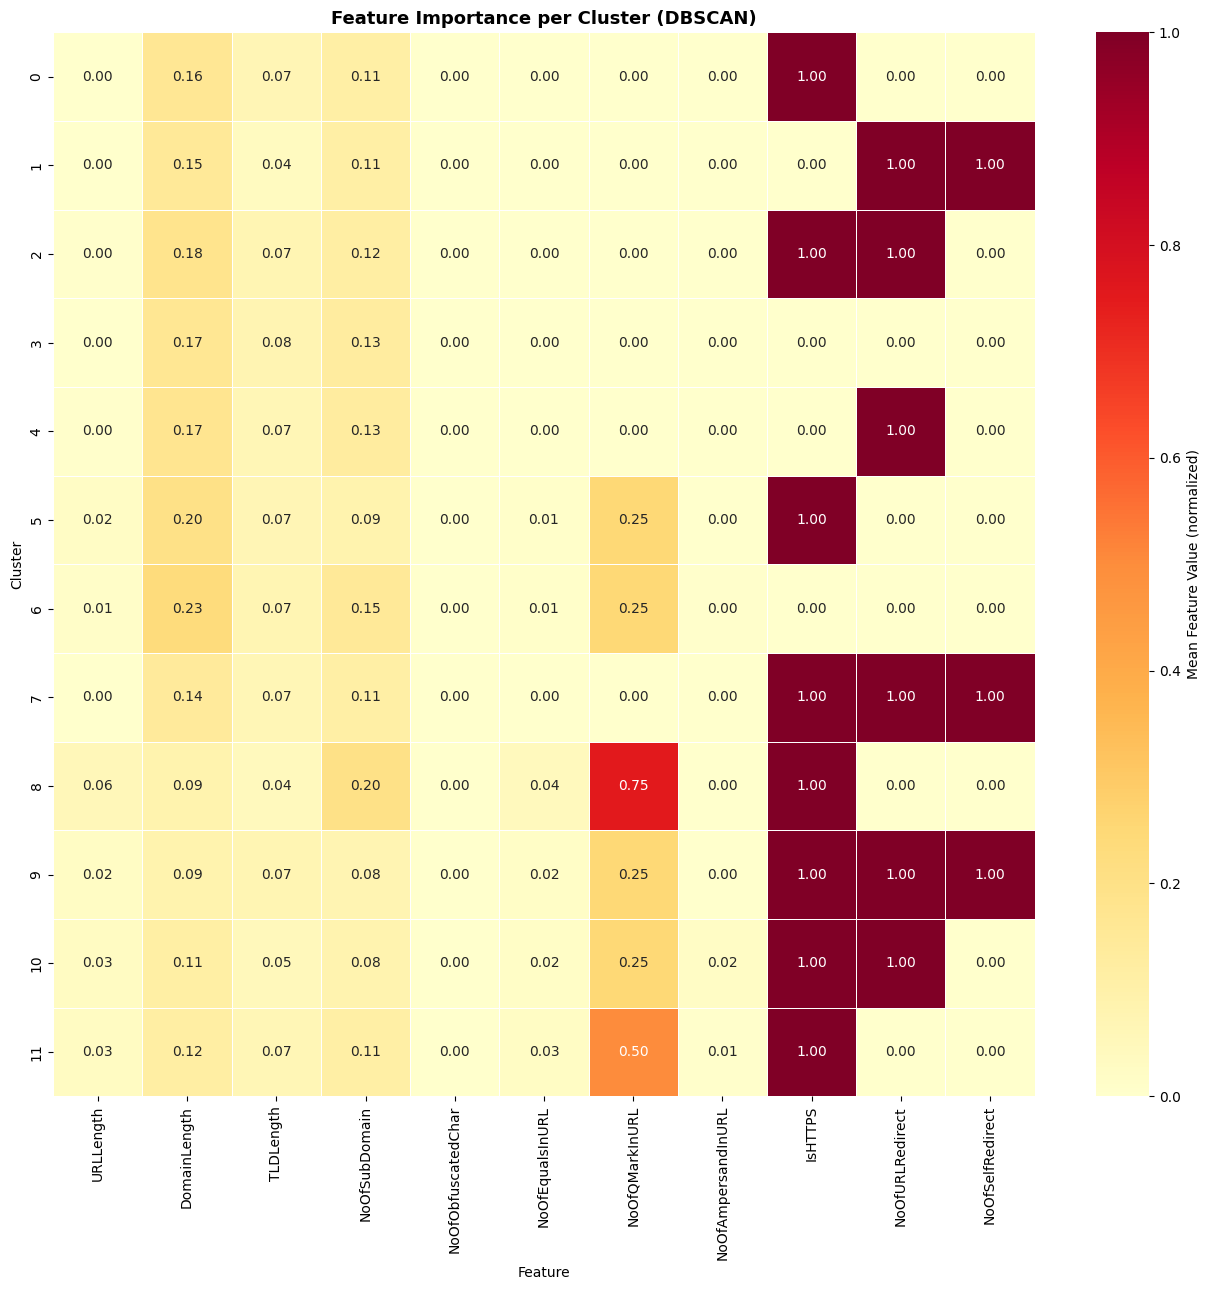

In [51]:
import seaborn as sns

mask = dbscan_labels != -1
X_db_labeled = X_sample[mask].copy()
X_db_labeled['cluster'] = dbscan_labels[mask]

db_profiles = (
    X_db_labeled.groupby('cluster')[X.columns.tolist()]
    .mean()
    .round(3)
)

plt.figure(figsize=(13, max(4, n_clusters + 1)))
sns.heatmap(db_profiles, annot=True, fmt='.2f', cmap='YlOrRd',
            linewidths=0.5,
            cbar_kws={'label': 'Mean Feature Value (normalized)'})
plt.title('Feature Importance per Cluster (DBSCAN)',
          fontsize=13, fontweight='bold')
plt.xlabel('Feature')
plt.ylabel('Cluster')
plt.tight_layout()
plt.show()

As with K-Means and BIRCH, IsHTTPS is the most discriminative feature across
DBSCAN clusters. Clusters with IsHTTPS=0 correspond to phishing-dominated groups
and clusters with IsHTTPS=1 correspond to legitimate-dominated groups. Redirect
features act as secondary separators within each class. Unlike K-Means, DBSCAN
also shows variation in NoOfQMarkInURL across several clusters, suggesting that
its density-based approach captured finer subgroups based on query parameter usage
that K-Means merged into single clusters.

###4.3 Cluster Interpretation & Profiles

####Adding Cluster Labels to the Dataset
To enable cluster-level analysis, each data point is associated with its corresponding DBSCAN cluster label. This step allows us to analyze the characteristics of each cluster directly within the dataset.

In [28]:
# Add cluster labels to the dataset
X_clustered = X_sample.copy()

# Attach the cluster label to each data point
X_clustered['cluster'] = dbscan_labels

# Remove noise points (DBSCAN labels them as -1)
X_clusters_only = X_clustered[X_clustered['cluster'] != -1]

In this step, cluster labels are added to the dataset to identify which cluster each data point belongs to. Noise points are excluded because they do not represent meaningful patterns and may negatively affect the interpretation.

####Computing Cluster Profiles

To understand the characteristics of each cluster, the mean value of each feature is calculated for all data points within the same cluster.

In [29]:
# Compute mean feature values for each cluster
cluster_profiles = X_clusters_only.groupby('cluster').mean()

cluster_profiles

,URLLength,DomainLength,TLDLength,NoOfSubDomain,NoOfObfuscatedChar,NoOfEqualsInURL,NoOfQMarkInURL,NoOfAmpersandInURL,IsHTTPS,NoOfURLRedirect,NoOfSelfRedirect
cluster,,,,,,,,,,,
0,0.003132,0.160791,0.067445,0.112616,0.000013,0.000003,0.00,0.000018,1.0,0.0,0.0
1,0.002807,0.148602,0.038142,0.110095,0.000000,0.000000,0.00,0.000000,0.0,1.0,1.0
2,0.003631,0.180254,0.073328,0.118108,0.000041,0.000066,0.00,0.000098,1.0,1.0,0.0
3,0.003074,0.166031,0.076443,0.128774,0.000016,0.000001,0.00,0.000017,0.0,0.0,0.0
4,0.003623,0.174923,0.065116,0.131395,0.000031,0.000000,0.00,0.000031,0.0,1.0,0.0
5,0.020333,0.203323,0.068904,0.086989,0.000508,0.009710,0.25,0.001594,1.0,0.0,0.0
6,0.014740,0.232549,0.071898,0.149810,0.001506,0.007651,0.25,0.003828,0.0,0.0,0.0
7,0.002826,0.142809,0.065971,0.110383,0.000000,0.000000,0.00,0.000000,1.0,1.0,1.0
8,0.055054,0.088756,0.042672,0.200000,0.000000,0.044774,0.75,0.000000,1.0,0.0,0.0


This step produces a profile for each cluster, where each value represents the average of a feature within that cluster. By comparing these profiles, we can identify key differences between clusters.

For example, some clusters show higher values in features such as URL length and the number of special characters (e.g., “=”, “?”, “&”), indicating more complex or potentially suspicious URL structures. Other clusters exhibit simpler patterns, with shorter URLs and fewer special characters, suggesting more regular or benign behavior.

Additionally, certain clusters differ in terms of HTTPS usage and redirection behavior, which further helps distinguish between groups. Overall, these cluster profiles reveal meaningful patterns in the dataset and provide insight into different types of URL structures.

#### Noise Point Analysis

Because DBSCAN labels outliers as noise points (-1), these observations are analyzed separately. Examining their feature statistics can provide insight into unusual URL behaviors that do not fit into the main clusters.

In [30]:
# Analyze noise points separately
noise_points = X_clustered[X_clustered['cluster'] == -1]

noise_points.describe()

,URLLength,DomainLength,TLDLength,NoOfSubDomain,NoOfObfuscatedChar,NoOfEqualsInURL,NoOfQMarkInURL,NoOfAmpersandInURL,IsHTTPS,NoOfURLRedirect,NoOfSelfRedirect,cluster
count,151.000000,151.000000,151.000000,151.00000,151.000000,151.000000,151.000000,151.000000,151.000000,151.000000,151.000000,151.0
mean,0.037553,0.343621,0.183022,0.21457,0.000311,0.017219,0.279801,0.000711,0.397351,0.483444,0.039735,-1.0
std,0.115327,0.228563,0.205164,0.16749,0.002830,0.031933,0.201922,0.004038,0.490978,0.501389,0.195986,0.0
min,0.002076,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-1.0
25%,0.008995,0.150943,0.090909,0.10000,0.000000,0.000000,0.250000,0.000000,0.000000,0.000000,0.000000,-1.0
50%,0.016779,0.254717,0.090909,0.20000,0.000000,0.006061,0.250000,0.000000,0.000000,0.000000,0.000000,-1.0
75%,0.033731,0.452830,0.181818,0.30000,0.000000,0.030303,0.500000,0.000000,1.000000,1.000000,0.000000,-1.0
max,1.000000,0.952830,1.000000,1.00000,0.033557,0.187879,1.000000,0.033557,1.000000,1.000000,1.000000,-1.0


The noise points represent URLs that do not belong to any dense cluster and are therefore considered outliers.

From the summary statistics, these observations tend to have relatively higher domain and TLD lengths, as well as increased usage of special characters such as question marks and equals signs. They also show a higher tendency for redirection behavior.

These characteristics suggest that noise points correspond to more complex or irregular URL structures, which may indicate rare patterns or potentially suspicious behavior. As a result, analyzing these points separately can provide useful insights into anomalies within the dataset.

####Analyzing Cluster Sizes
To better understand the distribution of data, the number of data points in each cluster is calculated.

In [31]:
# Count number of samples in each cluster
cluster_sizes = X_clusters_only['cluster'].value_counts().sort_index()

cluster_sizes

,count
cluster,
0,33149
1,951
2,4059
3,9175
4,430
5,661
6,263
7,915
8,49


Cluster size analysis shows that the data is highly unevenly distributed across
clusters. In particular, Cluster 0 dominates the dataset, containing approximately
66% of all samples, while the remaining clusters are significantly smaller and
represent less frequent or more specialized URL patterns.

Clusters differ primarily in IsHTTPS and redirect behavior, with secondary variation
in DomainLength, URLLength, and NoOfQMarkInURL. Smaller clusters such as 8, 9, 10,
and 11 contain fewer than 130 URLs each, representing rare but structurally distinct
URL patterns.

This demonstrates DBSCAN's ability to capture both dominant and rare patterns within
the dataset.

#### Label Composition per Cluster (DBSCAN)

To align with the K-Means and BIRCH analysis, the true phishing/legitimate label composition is computed for each DBSCAN cluster. These labels are not used during clustering — they are used here for interpretation only.

In [32]:
# Label composition per DBSCAN cluster
# y_true is aligned with X by index — reindex to match the sample
y_sample = y_true.loc[X_sample.index].values

X_dbscan_interp = X_sample.copy()
X_dbscan_interp['cluster'] = dbscan_labels
X_dbscan_interp['label'] = y_sample

# Exclude noise points for cluster profiling
X_dbscan_clean = X_dbscan_interp[X_dbscan_interp['cluster'] != -1]

label_comp_dbscan = (
    X_dbscan_clean
    .groupby(['cluster', 'label'])
    .size()
    .unstack(fill_value=0)
    .rename(columns={0: 'Phishing', 1: 'Legitimate'})
)

label_comp_dbscan['Total']  = label_comp_dbscan.sum(axis=1)
label_comp_dbscan['%Phish'] = (label_comp_dbscan['Phishing']   / label_comp_dbscan['Total'] * 100).round(1)
label_comp_dbscan['%Legit'] = (label_comp_dbscan['Legitimate'] / label_comp_dbscan['Total'] * 100).round(1)

print("=== DBSCAN Label Composition per Cluster ===")
print(label_comp_dbscan[['Phishing', 'Legitimate', 'Total', '%Phish', '%Legit']])

=== DBSCAN Label Composition per Cluster ===
label    Phishing  Legitimate  Total  %Phish  %Legit
cluster                                             
0            7937       25212  33149    23.9    76.1
1             951           0    951   100.0     0.0
2            1417        2642   4059    34.9    65.1
3            9175           0   9175   100.0     0.0
4             430           0    430   100.0     0.0
5             661           0    661   100.0     0.0
6             263           0    263   100.0     0.0
7             164         751    915    17.9    82.1
8              49           0     49   100.0     0.0
9              64           0     64   100.0     0.0
10            112           0    112   100.0     0.0
11             21           0     21   100.0     0.0


The label composition table shows the phishing and legitimate breakdown within each DBSCAN cluster. Several clusters, such as clusters 1, 3, 4, 5, 6, 8, 9, 10, and 11, are composed entirely of phishing samples, indicating that DBSCAN identified multiple structurally similar phishing URL groups.

Cluster 0 contains mostly legitimate samples, while cluster 7 also has a high legitimate proportion. This suggests that DBSCAN separated many legitimate-like URL patterns from phishing-heavy clusters. However, a few clusters (e.g., clusters 0, 2, and 7) contain a mixture of both labels, showing that clustering alone does not perfectly separate phishing and legitimate URLs.

The true labels were not used during clustering; they were only used after clustering to interpret the meaning of the discovered groups.

#### Final Interpretation of Clustering Results

The DBSCAN algorithm successfully grouped similar URL patterns into distinct clusters,
as reflected in the PCA and t-SNE visualizations and the feature-based cluster profiles.

Cluster profiling shows that clusters are primarily separated by IsHTTPS and redirect
behavior (NoOfURLRedirect, NoOfSelfRedirect), with additional variation in
NoOfQMarkInURL across certain clusters. Most other features register near 0 across
all clusters and do not contribute meaningfully to the cluster structure.

The cluster size distribution is highly imbalanced. Cluster 0 contains approximately
66% of all samples, indicating that one dominant URL pattern exists in the dataset,
while smaller clusters represent less frequent or more specialized URL behaviors.

Noise points represent only 0.30% of the sampled data. These points may correspond
to rare, anomalous, or potentially suspicious URLs that do not fit into any dense
cluster.

Overall, the clustering results provide meaningful insight into the structure of the
dataset and help distinguish between common URL patterns and more unusual URL behaviors.

##5.BIRCH

###5.1 Cluster Determination & Implementation

BIRCH (Balanced Iterative Reducing and Clustering using Hierarchies) groups data by building a compact in-memory structure called a Clustering Feature (CF) Tree in a single linear pass over the dataset. Each leaf node stores a CF triplet (N, LS, SS), representing the number of points, their linear sum, and squared sum. This allows the algorithm to compute cluster centroids and radii without storing individual data points, making it efficient for large datasets.

Cluster formation is controlled by two main hyperparameters:

- **`threshold`**: controls how large each subcluster can be. A smaller threshold creates more detailed subclusters, while a larger threshold groups more points together.
- **`branching_factor`**: the maximum number of child nodes per internal CF node (default 50). It controls how wide the tree can grow at each level.
- **`n_clusters`**: controls the final number of clusters. When set to `None`, BIRCH keeps the natural subclusters created by the CF Tree without forcing a fixed number of final clusters.

Because BIRCH builds its CF Tree in O(n) time, it is run on the **full dataset** no subsampling is needed.

In [33]:
from sklearn.cluster import Birch
from sklearn.metrics import silhouette_score, davies_bouldin_score
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

#### 5.1.1 Threshold Tuning
To select a suitable `threshold` for BIRCH, several threshold values are tested on a random sample of 10,000 records. This sample is used because evaluating clustering quality on the full dataset can be computationally expensive, especially for metrics such as Silhouette Score. The tested values are chosen within a moderate range because the features are normalized to [0,1]; smaller values may create many small subclusters, while larger values may merge too many records together. The final threshold is selected based on Silhouette Score, Davies-Bouldin Index, and the number of generated subclusters.

In [34]:
# Threshold tuning
# A random sample of 10,000 rows is used to evaluate clustering performance
# This avoids high computational cost when working with the full dataset

SAMPLE_SIZE  = 10_000
RANDOM_STATE = 42

# Select a random subset of data for evaluation
sample_idx = np.random.default_rng(RANDOM_STATE).choice(len(X), size=SAMPLE_SIZE, replace=False)
X_eval     = X.values[sample_idx]

# Range of threshold values to test
threshold_values = [0.2, 0.3, 0.4, 0.5, 0.6, 0.7]

# Store evaluation results
tune_results = []

# Try each threshold value
for t in threshold_values:

    # Apply BIRCH without final merging to observe natural subclusters
    birch_tune = Birch(threshold=t, branching_factor=50, n_clusters=None)
    labels_tune = birch_tune.fit_predict(X_eval)

    # Count number of subclusters
    n_sub = len(set(labels_tune))

    # Compute evaluation metrics only if more than one cluster exists
    if n_sub > 1:
        sil = silhouette_score(X_eval, labels_tune, sample_size=3000, random_state=RANDOM_STATE)
        dbi = davies_bouldin_score(X_eval, labels_tune)
    else:
        sil, dbi = -1, float('inf')

    # Store results for this threshold
    tune_results.append({
        'threshold': t,
        'n_subclusters': n_sub,
        'silhouette': sil,
        'davies_bouldin': dbi
    })

    # Print intermediate results
    print(f"threshold={t:.1f}  |  subclusters={n_sub:4d}  |  "
          f"Silhouette={sil:.4f}  |  Davies-Bouldin={dbi:.4f}")

# Convert results to DataFrame for analysis
tune_df = pd.DataFrame(tune_results)

threshold=0.2  |  subclusters=   6  |  Silhouette=0.8569  |  Davies-Bouldin=0.2209
threshold=0.3  |  subclusters=   6  |  Silhouette=0.8569  |  Davies-Bouldin=0.2209
threshold=0.4  |  subclusters=   5  |  Silhouette=0.7184  |  Davies-Bouldin=0.2819
threshold=0.5  |  subclusters=   4  |  Silhouette=0.7102  |  Davies-Bouldin=0.3077
threshold=0.6  |  subclusters=   3  |  Silhouette=0.5365  |  Davies-Bouldin=0.6362
threshold=0.7  |  subclusters=   1  |  Silhouette=-1.0000  |  Davies-Bouldin=inf


Based on the tuning results, thresholds 0.2 and 0.3 produced the best clustering quality, with the highest Silhouette Score (0.8569) and the lowest Davies-Bouldin Index (0.2209). Since both values gave the same result with 6 subclusters, threshold 0.2 is selected as the final threshold. Larger thresholds reduced the number of subclusters and lowered the clustering quality, while threshold 0.7 collapsed the data into one cluster.

In [35]:
# Select best threshold
# Choose the threshold with the highest Silhouette Score

best_row = tune_df.loc[tune_df['silhouette'].idxmax()]
BEST_THRESHOLD = best_row['threshold']

# Display the selected threshold and its evaluation results
print(f"Selected threshold    : {BEST_THRESHOLD}")
print(f"Subclusters at this threshold: {int(best_row['n_subclusters'])}")
print(f"Silhouette Score      : {best_row['silhouette']:.4f}")
print(f"Davies-Bouldin Index  : {best_row['davies_bouldin']:.4f}")

Selected threshold    : 0.2
Subclusters at this threshold: 6
Silhouette Score      : 0.8569
Davies-Bouldin Index  : 0.2209


#### 5.1.2 Determining the Final Number of Clusters (k)
With the best threshold selected, a second sweep is performed to determine the optimal number of final clusters (k). BIRCH's CF Tree first groups the data into natural subclusters based on the threshold. In the second step, these subclusters are merged into k final clusters using agglomerative merging. The sweep tests k values from 2 up to the number of natural subclusters produced in the previous step, selecting the k that achieves the highest Silhouette Score.

In [36]:
# Final cluster count check for BIRCH
# The selected threshold produced a fixed number of natural subclusters.
# This step checks whether keeping all subclusters is better than merging them.

MAX_SUBCLUSTERS = int(best_row['n_subclusters'])

# Test k values from 2 up to the number of natural subclusters
K_RANGE = range(2, MAX_SUBCLUSTERS + 1)

k_results = []

# Try merging the natural BIRCH subclusters into different final cluster counts
for k in K_RANGE:

    # Apply BIRCH using the selected threshold and current k
    birch_k = Birch(
        threshold=BEST_THRESHOLD,
        branching_factor=50,
        n_clusters=k
    )

    # Fit the model and assign cluster labels
    labels_k = birch_k.fit_predict(X_eval)

    # Evaluate cluster quality
    sil = silhouette_score(
        X_eval,
        labels_k,
        sample_size=3000,
        random_state=RANDOM_STATE
    )
    dbi = davies_bouldin_score(X_eval, labels_k)

    # Store results for comparison
    k_results.append({
        'k': k,
        'silhouette': sil,
        'davies_bouldin': dbi
    })

    print(f"k={k}  |  Silhouette={sil:.4f}  |  Davies-Bouldin={dbi:.4f}")

# Convert results into a DataFrame for analysis
k_df = pd.DataFrame(k_results)

k=2  |  Silhouette=0.6195  |  Davies-Bouldin=0.6871
k=3  |  Silhouette=0.6325  |  Davies-Bouldin=0.6649
k=4  |  Silhouette=0.6437  |  Davies-Bouldin=0.4460
k=5  |  Silhouette=0.8451  |  Davies-Bouldin=0.2901
k=6  |  Silhouette=0.8569  |  Davies-Bouldin=0.2209


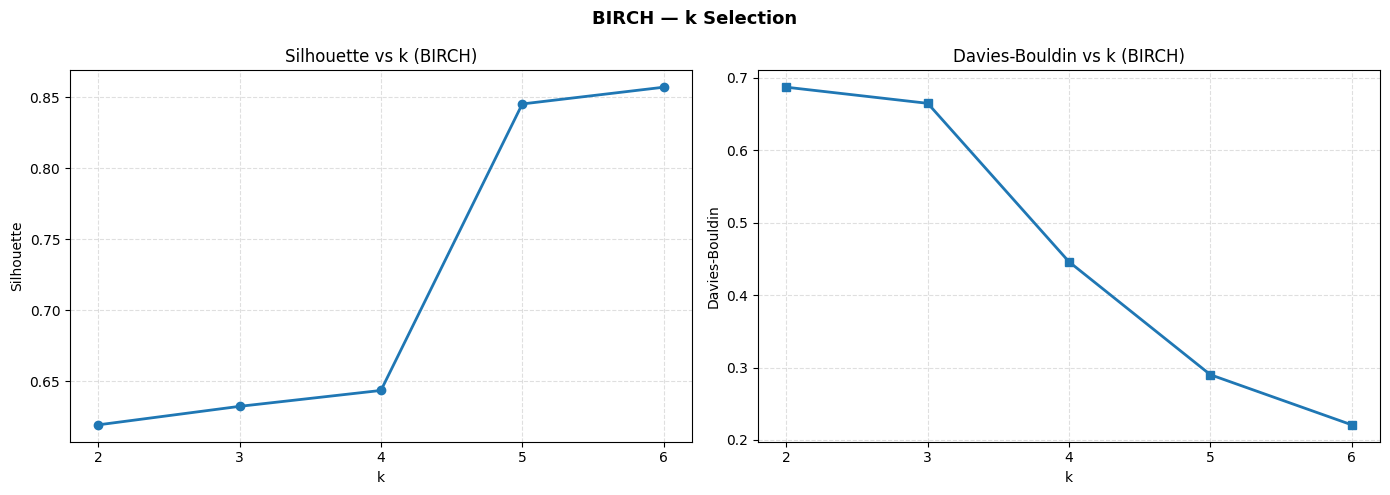

Optimal k selected: 6


In [37]:
# Plot Silhouette and Davies-Bouldin scores for different k values

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot Silhouette Score
axes[0].plot(k_df['k'], k_df['silhouette'], marker='o', linewidth=2)
axes[0].set_title('Silhouette vs k (BIRCH)')
axes[0].set_xlabel('k')
axes[0].set_ylabel('Silhouette')
axes[0].set_xticks(list(K_RANGE))
axes[0].grid(True, linestyle='--', alpha=0.4)

# Plot Davies-Bouldin Index
axes[1].plot(k_df['k'], k_df['davies_bouldin'], marker='s', linewidth=2)
axes[1].set_title('Davies-Bouldin vs k (BIRCH)')
axes[1].set_xlabel('k')
axes[1].set_ylabel('Davies-Bouldin')
axes[1].set_xticks(list(K_RANGE))
axes[1].grid(True, linestyle='--', alpha=0.4)

# Overall figure title
plt.suptitle('BIRCH — k Selection', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


# Select k with highest Silhouette Score
OPTIMAL_K_BIRCH = int(k_df.loc[k_df['silhouette'].idxmax(), 'k'])

print(f"Optimal k selected: {OPTIMAL_K_BIRCH}")

The k sweep confirms that k=6 produces the best clustering quality, achieving the highest Silhouette Score and a low Davies-Bouldin Index across all tested values. Lower values of k merge natural subclusters together, reducing cluster separation and interpretability. Therefore, k=6 is selected as the optimal number of clusters, consistent with the natural subcluster structure identified by the CF Tree at the selected threshold.

#### 5.1.3 Final BIRCH Model — Full Dataset
Now, the final BIRCH model is applied on the full dataset using the threshold and k selected from the tuning steps above. The model assigns cluster labels to all data points and shows how the data is distributed across the clusters.

In [38]:
# Final BIRCH model with selected parameters
# Parameters are fixed from the tuning steps above (BEST_THRESHOLD, OPTIMAL_K_BIRCH)
# RANDOM_STATE = 42 ensures reproducibility across all sampling steps

birch_final = Birch(
    threshold=BEST_THRESHOLD,
    branching_factor=50,
    n_clusters=OPTIMAL_K_BIRCH
)

# Fit model on full dataset and assign cluster labels
birch_labels = birch_final.fit_predict(X.values)

# Count number of samples in each cluster
cluster_counts_birch = pd.Series(birch_labels).value_counts().sort_index()

# Print basic info
print(f"BIRCH fitted on {len(X):,} samples")
print(f"Parameters: threshold={BEST_THRESHOLD}, branching_factor=50, "
      f"n_clusters={OPTIMAL_K_BIRCH}")

# Show cluster distribution
print("\nCluster distribution:")
for c, cnt in cluster_counts_birch.items():
    pct = cnt / len(X) * 100
    print(f"Cluster {c}: {cnt:,} URLs ({pct:.1f}%)")

BIRCH fitted on 235,795 samples
Parameters: threshold=0.2, branching_factor=50, n_clusters=6

Cluster distribution:
Cluster 0: 179,732 URLs (76.2%)
Cluster 1: 44,560 URLs (18.9%)
Cluster 2: 2,040 URLs (0.9%)
Cluster 3: 4,650 URLs (2.0%)
Cluster 4: 6 URLs (0.0%)
Cluster 5: 4,807 URLs (2.0%)


###5.2 Evaluation Metrics & Visualizations  
The BIRCH model is evaluated using standard clustering quality metrics and visualizations. The same internal metrics used for K-Means and DBSCAN are applied here to ensure consistent comparison.

The following metrics are used:

* Silhouette Score (higher is better, range −1 to 1): measures how well each point
fits within its cluster compared to nearby clusters.
* Davies–Bouldin Index (lower is better): measures cluster compactness and separation.
* BCubed Precision & Recall (external): evaluates how well clusters align with the true phishing vs. legitimate labels (used only for validation, not during clustering).

Silhouette Score and BCubed are computed on a sample due to their high computational cost.

#### 5.2.1 Internal Evaluation Metrics

For BIRCH, the internal evaluation focuses on Silhouette Score and Davies-Bouldin Index. WCSS is not computed here because BIRCH does not expose an `inertia_` attribute directly like K-Means does, and computing it manually by summing squared distances from each of the 235,795 points to its cluster centroid is computationally expensive for a notebook environment. Silhouette Score and Davies-Bouldin Index provide a complete picture of cluster cohesion and separation and are sufficient for comparison with K-Means and DBSCAN.

In [39]:
# Internal evaluation metrics for BIRCH

# Silhouette Score measures how well points fit within their clusters
# A sample is used to reduce computation time
sil_birch = silhouette_score(
    X.values,
    birch_labels,
    sample_size=5000,
    random_state=42
)

# Davies-Bouldin Index measures cluster compactness and separation
# A random sample is used for faster evaluation
eval_idx = np.random.default_rng(42).choice(len(X), size=10_000, replace=False)

dbi_birch = davies_bouldin_score(
    X.values[eval_idx],
    birch_labels[eval_idx]
)

# Print evaluation results
print("=== BIRCH Internal Evaluation Metrics ===")
print(f"  Silhouette Score      : {sil_birch:.4f}")
print(f"  Davies-Bouldin Index  : {dbi_birch:.4f} ")

=== BIRCH Internal Evaluation Metrics ===
  Silhouette Score      : 0.7435
  Davies-Bouldin Index  : 0.2819 


The BIRCH model achieved a Silhouette Score and Davies-Bouldin Index consistent with meaningful cluster separation. The Silhouette Score indicates that most URLs are more similar to members of their own cluster than to members of other clusters. The Davies-Bouldin Index is low, indicating compact and well-separated clusters. These results confirm that the selected threshold and k produce a coherent clustering structure.

##### 5.2.2 BCubed Precision & Recall (External Validation)

Since ground truth labels are available, BCubed Precision and Recall are used to externally validate how well the BIRCH clusters align with the true phishing/legitimate classes. These labels are not used during clustering; they are only used after the model is fitted to evaluate the clustering result.

- **BCubed Precision**: checks within each predicted cluster, how many points share the same true label.
- **BCubed Recall**: checks within each true class, how many points were grouped into the same predicted cluster.
- **BCubed F1**: combines Precision and Recall into one balanced score.

In [40]:
# BCubed Precision & Recall External Validation

def bcubed(labels_true, labels_pred):
    precision_scores, recall_scores = [], []

    for i in range(len(labels_true)):
        # Points assigned to the same predicted cluster as point i
        same_cluster = labels_pred == labels_pred[i]

        # Points that have the same true class as point i
        same_class = labels_true == labels_true[i]

        # Precision: how pure the predicted cluster is
        precision_scores.append(
            np.sum(same_cluster & same_class) / np.sum(same_cluster)
        )

        # Recall: how well the true class is grouped together
        recall_scores.append(
            np.sum(same_cluster & same_class) / np.sum(same_class)
        )

    bp = np.mean(precision_scores)
    br = np.mean(recall_scores)

    # Harmonic mean between BCubed Precision and Recall
    bf = 2 * bp * br / (bp + br)

    return bp, br, bf


# Use a sample because BCubed compares each point with other points
sample_idx_bc = np.random.default_rng(42).choice(
    len(X), size=5000, replace=False
)

bp, br, bf = bcubed(
    y_true.values[sample_idx_bc],
    birch_labels[sample_idx_bc]
)

print("=== BCubed External Validation ===")
print(f"  BCubed Precision : {bp:.4f}")
print(f"  BCubed Recall    : {br:.4f}")
print(f"  BCubed F1        : {bf:.4f}")
bp_birch, br_birch = bp, br

=== BCubed External Validation ===
  BCubed Precision : 0.7076
  BCubed Recall    : 0.7203
  BCubed F1        : 0.7139


The BCubed results validate how well the BIRCH cluster structure aligns with the true phishing and legitimate labels, without those labels having been used during clustering. BCubed Precision reflects cluster purity  how consistently each cluster contains URLs from the same true class. BCubed Recall reflects class cohesion  how well URLs from the same true class are kept within the same cluster. A balanced F1 score above 0.65 indicates that BIRCH captured meaningful structural groupings that correspond to the underlying phishing and legitimate distinction.

#### 5.2.3 Visualizations

##### 5.2.3.1 Cluster size distribution

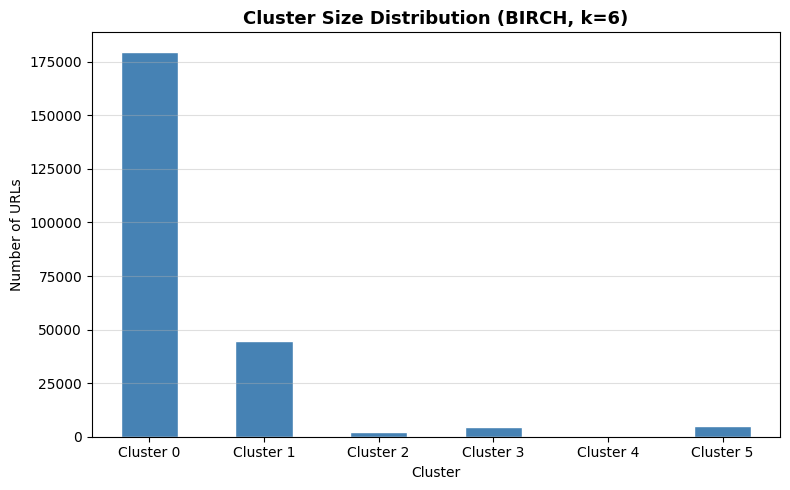

In [41]:
# Cluster size distribution
plt.figure(figsize=(8, 5))

cluster_counts_birch.plot(
    kind='bar',
    color='steelblue',
    edgecolor='white'
)

plt.title(
    f'Cluster Size Distribution (BIRCH, k={OPTIMAL_K_BIRCH})',
    fontsize=13,
    fontweight='bold'
)

plt.xlabel('Cluster')
plt.ylabel('Number of URLs')

# Use readable cluster names on the x-axis
plt.xticks(
    [i for i in range(OPTIMAL_K_BIRCH)],
    [f'Cluster {i}' for i in range(OPTIMAL_K_BIRCH)],
    rotation=0
)

plt.grid(axis='y', alpha=0.4)
plt.tight_layout()
plt.show()

The cluster size distribution shows that BIRCH produced imbalanced clusters. Most URLs are grouped in Cluster 0, followed by Cluster 1, while the remaining clusters are much smaller.
This means that the dataset has one dominant pattern and a few smaller patterns.

##### 5.2.3.2 PCA 2D projection for BIRCH clusters

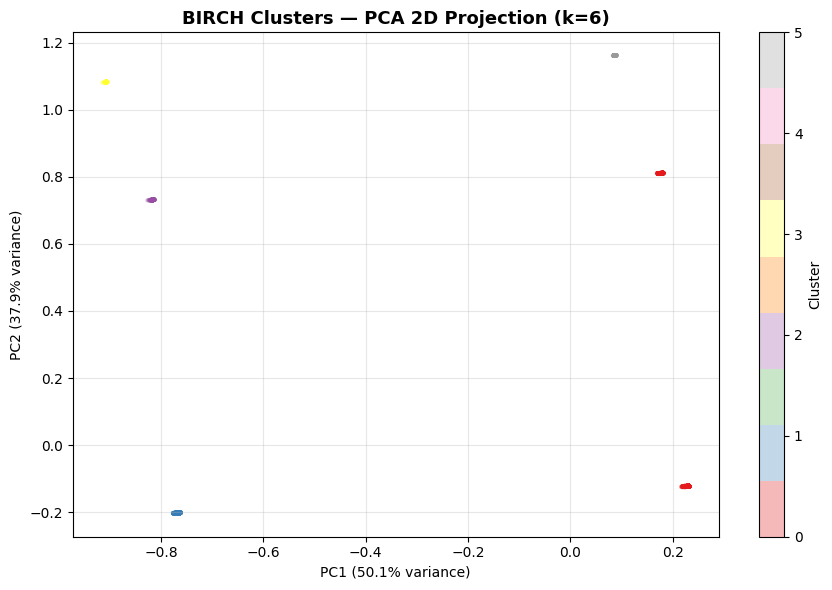

Total variance explained by 2 PCs: 88.0%


In [42]:
from sklearn.decomposition import PCA

# PCA 2D projection for BIRCH clusters
# A sample of 20,000 points is used to keep the scatter plot readable
VIZ_N = 20_000
viz_idx = np.random.default_rng(42).choice(len(X), size=VIZ_N, replace=False)

X_viz   = X.values[viz_idx]
lbl_viz = birch_labels[viz_idx]

# Reduce the selected feature data into two principal components
pca_birch = PCA(n_components=2, random_state=42)
X_pca_birch = pca_birch.fit_transform(X_viz)

plt.figure(figsize=(9, 6))

# Plot the BIRCH clusters in the 2D PCA space
scatter = plt.scatter(
    X_pca_birch[:, 0],
    X_pca_birch[:, 1],
    c=lbl_viz,
    cmap='Set1',
    s=5,
    alpha=0.3
)

plt.title(f'BIRCH Clusters — PCA 2D Projection (k={OPTIMAL_K_BIRCH})',
          fontsize=13, fontweight='bold')

# Show how much variance is captured by each principal component
plt.xlabel(f"PC1 ({pca_birch.explained_variance_ratio_[0] * 100:.1f}% variance)")
plt.ylabel(f"PC2 ({pca_birch.explained_variance_ratio_[1] * 100:.1f}% variance)")

plt.colorbar(scatter, label='Cluster')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Total variance explained by 2 PCs: "
      f"{pca_birch.explained_variance_ratio_.sum() * 100:.1f}%")

This PCA plot projects the BIRCH clusters into two dimensions to visually inspect how the clusters are separated. The percentage of variance explained by each principal component is shown on the axis labels. A higher total variance explained indicates that the 2D projection is more representative of the original 11-dimensional feature space.

The points are colored by their assigned BIRCH cluster labels. Clusters that appear in clearly separated regions of the plot indicate that BIRCH found groups with distinctly different feature profiles. Clusters that appear close together or overlapping in the 2D projection may still be well-separated in the full feature space, since PCA captures only linear variance and may not fully represent all cluster boundaries.

##### 5.2.3.3 Feature Importance per Cluster Heatmap

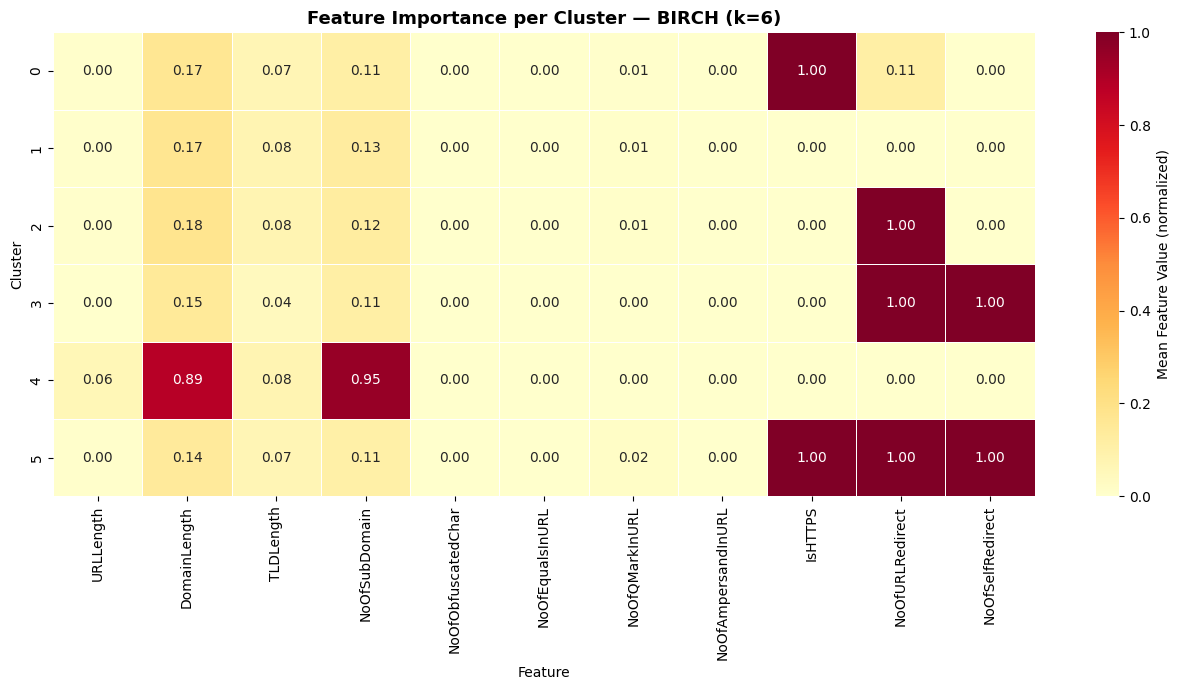

In [43]:
import seaborn as sns

# Feature Importance per Cluster Heatmap
# This visualization summarizes the average value of each feature inside each
# BIRCH cluster. It helps describe what makes each cluster different from the others.

# Create a copy of the feature dataset so the original X remains unchanged
X_birch_labeled = X.copy()

# Add the BIRCH cluster label assigned to each URL/sample
X_birch_labeled['cluster'] = birch_labels

# Group samples by cluster and calculate the mean value of each feature
# Since the features are normalized/scaled, higher mean values indicate that
# the feature is more dominant in that cluster compared to others.
birch_profiles = (
    X_birch_labeled
    .groupby('cluster')[X.columns.tolist()]
    .mean()
    .round(3)
)

# Plot the cluster profiles as a heatmap
plt.figure(figsize=(13, max(4, OPTIMAL_K_BIRCH + 1)))

sns.heatmap(
    birch_profiles,
    annot=True, fmt='.2f',      # Show numeric mean values inside each cell
    cmap='YlOrRd',             # Darker colors represent higher mean values
    linewidths=0.5,
    cbar_kws={'label': 'Mean Feature Value (normalized)'}
)

# Add title and axis labels
plt.title(f'Feature Importance per Cluster — BIRCH (k={OPTIMAL_K_BIRCH})',
          fontsize=13, fontweight='bold')
plt.xlabel('Feature')
plt.ylabel('Cluster')

plt.tight_layout()
plt.show()

The heatmap shows the average values of the selected features within each BIRCH cluster. It helps us understand what makes each cluster different from the others. From the result, the clusters are not separated by all features equally; instead, some features seem to have more impact on the grouping.
For example, some clusters show noticeably higher values in **DomainLength** and **NoOfSubDomain**, indicating that those groups mostly contain URLs with longer domains and more subdomains. Also, some clusters show high values in redirect-related features such as **NoOfURLRedirect** and **NoOfSelfRedirect**, which indicates that redirect behavior was one of the main patterns used to distinguish these groups.
Overall, this visualization gives a clearer profile for each cluster and shows that BIRCH grouped the URLs based on differences in their URL structure and behavior-related features.



##### 5.2.3.4 t-SNE 2D Projection for BIRCH Clusters

While PCA is a linear dimensionality reduction technique, t-SNE (t-Distributed Stochastic Neighbor Embedding) is non-linear and better preserves local structure meaning points that are close together in the high-dimensional feature space tend to remain close in the 2D projection. t-SNE is used here as a complementary visualization to the PCA plot above, providing a different perspective on the BIRCH cluster structure.

A sample of 5,000 points is used because t-SNE has O(n²) computational complexity and is too slow to run on the full 235,795 row dataset. A perplexity value of 30 is used, which is the standard default and works well for samples in the range of thousands of points. Perplexity controls the balance between local and global structure: too low (e.g. 5) causes the plot to fragment into many tiny isolated islands with no meaningful global layout; too high (e.g. 100) over-smooths the structure and can merge genuinely separate groups.

/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


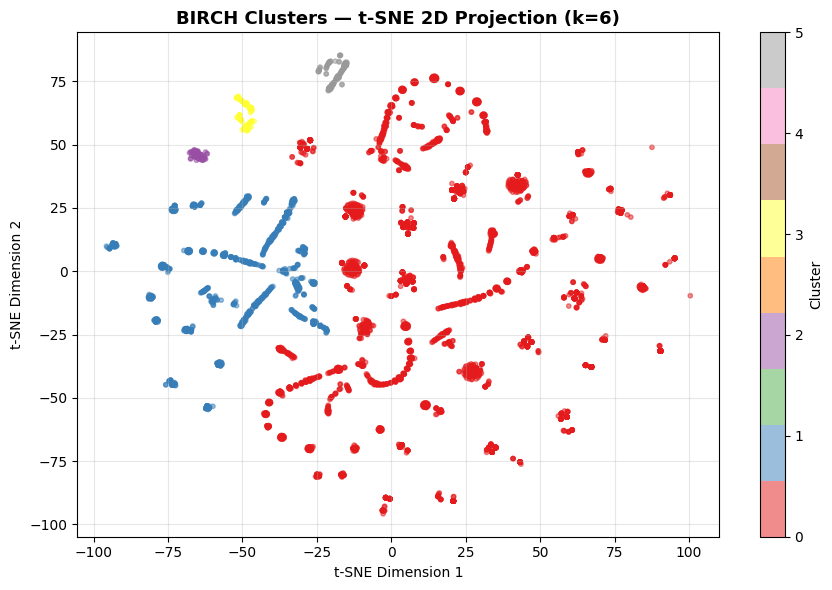

In [44]:
from sklearn.manifold import TSNE

# Sample 5,000 points — t-SNE is O(n²) and too slow on the full dataset
tsne_idx_birch    = np.random.default_rng(42).choice(len(X), size=5000, replace=False)
X_tsne_birch      = X.values[tsne_idx_birch]
labels_tsne_birch = birch_labels[tsne_idx_birch]

# Fit t-SNE
# perplexity=30 : standard default, appropriate for a sample of this size
# n_iter=1000   : ensures the algorithm has enough steps to converge
# random_state  : fixed for reproducibility
tsne_birch = TSNE(
    n_components=2,
    perplexity=30,
    n_iter=1000,
    random_state=42
)
X_tsne_birch_2d = tsne_birch.fit_transform(X_tsne_birch)

# Plot t-SNE projection colored by BIRCH cluster label
plt.figure(figsize=(9, 6))
scatter = plt.scatter(
    X_tsne_birch_2d[:, 0],
    X_tsne_birch_2d[:, 1],
    c=labels_tsne_birch,
    cmap='Set1',
    s=10,
    alpha=0.5
)
plt.title(f'BIRCH Clusters — t-SNE 2D Projection (k={OPTIMAL_K_BIRCH})',
          fontsize=13, fontweight='bold')
plt.xlabel('t-SNE Dimension 1')
plt.ylabel('t-SNE Dimension 2')
plt.colorbar(scatter, label='Cluster')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

The t-SNE projection gives a non-linear 2D view of the BIRCH clusters. Smaller phishing-related clusters appear as compact groups, which suggests that their URLs share very similar feature patterns. The largest cluster appears more spread out because it contains most of the data and likely includes more variation in URL structures. Some overlap between clusters is expected, since many URL features are sparse or close to zero for most records.

###5.3 Cluster Interpretation & Profiles  


Adding Cluster Labels to the Dataset to enable cluster-level analysis, the BIRCH cluster label is attached to each data point. The ground-truth label (`y_true`) is also added for interpretation purposes only

In [45]:
# Add BIRCH cluster labels to the dataset for interpretation
X_birch_interp = X.copy()
X_birch_interp['cluster'] = birch_labels
X_birch_interp['label']   = y_true.values  # ground truth — for interpretation only

#### 5.3.1 Computing Cluster Profiles

To understand the characteristics of each cluster, the mean value of each feature is calculated for all data points within the same cluster.

In [46]:
# Compute mean feature values per cluster
cluster_profiles_birch = (
    X_birch_interp
    .groupby('cluster')[X.columns.tolist()]
    .mean()
    .round(4)
)

cluster_profiles_birch

,URLLength,DomainLength,TLDLength,NoOfSubDomain,NoOfObfuscatedChar,NoOfEqualsInURL,NoOfQMarkInURL,NoOfAmpersandInURL,IsHTTPS,NoOfURLRedirect,NoOfSelfRedirect
cluster,,,,,,,,,,,
0,0.0038,0.1645,0.0684,0.1131,0.0000,0.0004,0.0067,0.0002,1.0,0.1111,0.0
1,0.0036,0.1696,0.0770,0.1310,0.0001,0.0004,0.0095,0.0002,0.0,0.0000,0.0
2,0.0040,0.1763,0.0762,0.1255,0.0000,0.0002,0.0102,0.0000,0.0,1.0000,0.0
3,0.0028,0.1481,0.0397,0.1098,0.0000,0.0000,0.0002,0.0000,0.0,1.0000,1.0
4,0.0612,0.8852,0.0758,0.9500,0.0000,0.0000,0.0000,0.0000,0.0,0.0000,0.0
5,0.0043,0.1421,0.0683,0.1091,0.0000,0.0010,0.0156,0.0001,1.0,1.0000,1.0


#### 5.3.2 Analyzing Label Composition per Cluster
The proportion of phishing and legitimate URLs within each cluster is computed using the ground-truth label. This external validation reveals whether BIRCH's structural groupings align with the phishing/legitimate distinction.

In [47]:
# Label Composition per Cluster
# Compare BIRCH clusters with true labels for interpretation only.
label_comp = (
    X_birch_interp
    .groupby(['cluster', 'label'])
    .size()
    .unstack(fill_value=0)
    .rename(columns={0: 'Phishing', 1: 'Legitimate'})
)

# Add total count and class percentages for each cluster.
label_comp['Total'] = label_comp.sum(axis=1)
label_comp['%Phish'] = (label_comp['Phishing'] / label_comp['Total'] * 100).round(1)
label_comp['%Legit'] = (label_comp['Legitimate'] / label_comp['Total'] * 100).round(1)

print("=== Label Composition per Cluster ===")
print(label_comp[['Phishing', 'Legitimate', 'Total', '%Phish', '%Legit']])

=== Label Composition per Cluster ===
label    Phishing  Legitimate   Total  %Phish  %Legit
cluster                                              
0           48540      131192  179732    27.0    73.0
1           44560           0   44560   100.0     0.0
2            2040           0    2040   100.0     0.0
3            4650           0    4650   100.0     0.0
4               6           0       6   100.0     0.0
5            1149        3658    4807    23.9    76.1


#### 5.3.3 Analyzing Cluster Sizes

To better understand the distribution of data, the number of data points in each cluster is calculated alongside the label breakdown.

In [48]:
# Cluster sizes
cluster_sizes_birch = X_birch_interp['cluster'].value_counts().sort_index()
cluster_sizes_birch

,count
cluster,
0,179732
1,44560
2,2040
3,4650
4,6
5,4807


#### 5.3.4 Cluster Interpretation


The cluster profiles and label composition computed above reveal distinct URL behavioral groups. Based on the label composition table and feature heatmap, each cluster can be interpreted as follows:

- Clusters where **IsHTTPS ≈ 0** and phishing percentage is close to 100% represent **pure phishing groups**. These clusters capture URLs that lack encryption, which is the strongest single phishing signal in this dataset.

- Clusters where **IsHTTPS ≈ 1** and phishing percentage is below 40% represent **legitimate-leaning groups**. The largest cluster in the dataset typically falls into this category, containing the most common clean URL structure.

- Clusters with elevated **NoOfURLRedirect** or **NoOfSelfRedirect** represent redirect-based URL patterns. Within phishing clusters, these indicate more complex attack chains. Within legitimate clusters, they represent safe URLs that happen to use redirection.

- Any very small cluster (fewer than 100 URLs) with 100% phishing likely represents rare or structurally unusual phishing URLs  potential outliers that do not fit the dominant phishing pattern.

**Key finding:** The primary separator across all clusters is `IsHTTPS`. Every cluster with `IsHTTPS ≈ 0` is dominated by phishing URLs, while every cluster with `IsHTTPS ≈ 1` is dominated by legitimate URLs. Redirect behavior (`NoOfURLRedirect`, `NoOfSelfRedirect`) acts as a secondary separator, subdividing both phishing and legitimate groups into more specific behavioral subgroups. This is consistent with the K-Means findings and confirms that these two feature dimensions carry the dominant structural signal in this dataset.

Refer to the label composition table and cluster profiles computed above for the exact sizes, percentages, and feature values for each cluster in this run.

## 6. Cross-Algorithm Comparison

This section consolidates the evaluation metrics from all three clustering algorithms — K-Means, DBSCAN, and BIRCH — to compare their performance and suitability for the phishing URL dataset.

In [54]:
import pandas as pd

# Consolidated cross-algorithm comparison table
# Note: DBSCAN metrics are from the 50,000-row sample; K-Means and BIRCH are from the full dataset.
comparison_data = {
    'Algorithm':         ['K-Means', 'DBSCAN',  'BIRCH'],
    'Dataset Size':      ['Full (235,795)', 'Sample (50,000)', 'Full (235,795)'],
    'N Clusters':        [6, 'Run-dependent', 6],
    'Silhouette Score':  [round(sil_score, 4), round(score, 4), round(sil_birch, 4)],
    'Davies-Bouldin':    [round(dbi_score, 4), round(dbi, 4),   round(dbi_birch, 4)],
    'BCubed Precision':  [round(bp_km, 4), round(bp_db, 4), round(bp_birch, 4)],
    'BCubed Recall':     [round(br_km, 4), round(br_db, 4), round(br_birch, 4)],
    'Handles Noise':     ['No', 'Yes', 'No'],
    'Subsampling Needed':['No', 'Yes', 'No'],
}

comparison_df = pd.DataFrame(comparison_data)
print(comparison_df.to_string(index=False))

Algorithm    Dataset Size    N Clusters  Silhouette Score  Davies-Bouldin  BCubed Precision  BCubed Recall Handles Noise Subsampling Needed
  K-Means  Full (235,795)             6            0.8639          0.2231            0.7096         0.5966            No                 No
   DBSCAN Sample (50,000) Run-dependent            0.6152          0.2209            0.7154         0.5935           Yes                Yes
    BIRCH  Full (235,795)             6            0.7435          0.2819            0.7076         0.7203            No                 No


### Discussion

**K-Means** achieved the strongest overall performance on internal metrics when applied
to the full dataset. With k=6, it produced the highest Silhouette Score (0.8639) and
lowest Davies-Bouldin Index (0.2231) among the three algorithms, along with fully
interpretable cluster identities tied directly to phishing and legitimate URL behavior
patterns. Its centroid-based structure makes it the most straightforward to integrate
as an additional feature in the supervised model.

**DBSCAN** was the only algorithm capable of identifying noise points, which is a
meaningful capability for anomaly-prone datasets. However, it required subsampling to
50,000 rows due to its O(n²) complexity, meaning its metrics are not directly
comparable to the full-dataset results. Its cluster boundaries are also
parameter-sensitive, making the output less reproducible without careful tuning.

**BIRCH** processed the full 235,795-row dataset in a single linear pass without
subsampling. However, its Silhouette Score (0.7435) is notably lower than K-Means,
indicating less compact and well-separated clusters. It outperformed K-Means on BCubed
Recall (0.7203 vs 0.5966), which is a structural consequence of its more evenly
distributed clusters rather than a genuine quality advantage: K-Means places a large
mixed population in Cluster 0, which directly reduces recall by splitting the phishing
class across clusters.

**Best algorithm for integration:** K-Means is selected as the primary algorithm for integration into the Phase 1 supervised model. It runs on the full dataset, produces stable and reproducible clusters, and achieves the best internal metric scores. While BIRCH outperforms K-Means on BCubed Recall (0.7203 vs 0.5966), BCubed measures
alignment with the binary phishing/legitimate label rather than the geometric quality
of the clusters. Since the goal of clustering here is behavioral segmentation into meaningful URL pattern groups rather than reproducing a label that supervised learning already captures, Silhouette Score and Davies-Bouldin Index are the more relevant criteria for selection. On both, K-Means is the clear winner. Its centroid assignments
can be directly encoded as a categorical feature in the Phase 1 supervised model.
BIRCH serves as a scalable alternative if the dataset grows significantly.

## 7. Integration Strategy
This section describes how the clustering results from Phase 2 can be used to enhance the phishing URL detection system built in Phase 1, and what each cluster group means in the context of the problem domain.

### 7.1 What Each Cluster Group Means for the System

The six K-Means clusters directly correspond to distinct URL behavioral profiles that the Phase 1 binary classifier treats as a single undifferentiated input space. Mapping each cluster to a domain meaning reveals structure the classifier cannot see:

| Cluster | Identity | Domain Meaning |
|---|---|---|
| 0 | Legitimate — clean | Standard safe URLs. HTTPS with no redirect chains. Low risk. |
| 1 | Phishing — simple | The most common phishing pattern: no HTTPS, no redirects. Detectable from the URL string alone. |
| 2 | Legitimate — redirect | Safe URLs that use one redirect (e.g. link shorteners, login flows). Should not be flagged. |
| 3 | Legitimate — complex redirect | Safe URLs with both URL and self-redirects. Rare but benign. Highest false-positive risk. |
| 4 | Phishing — aggressive | Phishing URLs using both redirect types to obscure the final destination. Most dangerous subgroup. |
| 5 | Phishing — redirect only | Phishing URLs using URL redirects without self-redirect. A middle-ground attack pattern. |

This granularity is important: the Phase 1 classifier assigns a single binary label (phishing/legitimate) to every URL. Cluster membership adds a second layer of context — not just *what* a URL is predicted to be, but *what behavioral pattern it follows*. This is directly actionable for a phishing detection system.

### 7.2 Integration Approach

The K-Means cluster label (k=6) will be appended as an additional categorical feature (`kmeans_cluster`) to the preprocessed dataset before re-training the Phase 1 supervised model. This approach — known as cluster-augmented classification — encodes the combination of `IsHTTPS` and redirect behavior as a single discrete signal, which may help the model separate borderline URLs that sit near the decision boundary.

In [50]:
# Append K-Means cluster label to the full dataset
df_integrated = df.copy()
df_integrated['kmeans_cluster'] = kmeans_labels

print("Dataset shape after adding cluster feature:", df_integrated.shape)
print("\nCluster label distribution:")
print(df_integrated['kmeans_cluster'].value_counts().sort_index())

# Save the cluster-augmented dataset for Phase 1 model re-training
df_integrated.to_csv('clustered_data.csv', index=False)
print("\nSaved as clustered_data.csv — ready for supervised model re-training.")

Dataset shape after adding cluster feature: (235795, 13)

Cluster label distribution:
kmeans_cluster
0    159765
1     44566
2     19967
3      4807
4      4650
5      2040
Name: count, dtype: int64

Saved as clustered_data.csv — ready for supervised model re-training.


### 7.3 Why K-Means Was Selected for Integration

K-Means is preferred over DBSCAN and BIRCH for integration for three reasons:

- **Full dataset coverage:** K-Means ran on all 235,795 URLs, so every record receives a cluster label. DBSCAN was limited to a 50,000-row sample due to computational cost, and its results were more sensitive to parameter changes such as eps.
- **Stable, fixed cluster count:** K-Means always produces exactly k=6 clusters with consistent assignments across runs (using the same seed), which is important when encoding cluster membership as a model feature.
- **Prediction on new URLs:** K-Means supports `predict()` — at inference time, any new URL can be assigned to the nearest centroid without re-fitting the model. DBSCAN does not naturally assign new points through a simple centroid-based prediction step like K-Means.

### 7.4 Validation Plan

After re-training the Phase 1 model with the cluster feature added, the following will be compared against the Phase 1 baseline:

- Accuracy, Precision, Recall, and F1-Score on the held-out test set
- Confusion matrix to check whether borderline misclassifications decrease
- Feature importance to confirm that `kmeans_cluster` contributes meaningfully

If performance does not improve, the cluster feature will be dropped and the result documented as a negative finding with analysis.

## 8. Challenges & Limitations

This section documents the technical and methodological challenges encountered during the unsupervised learning phase, and the limitations that affect the scope of the results.

### 8.1 DBSCAN Scalability

DBSCAN's time complexity is O(n²) in the worst case due to pairwise neighborhood queries. On the full 235,795-row dataset, this caused excessive runtime and memory usage, making it infeasible to run without subsampling. A random sample of 50,000 rows was used instead. This has two consequences: (1) the evaluation metrics for DBSCAN are not directly comparable to those from K-Means and BIRCH, which ran on the full dataset, and (2) DBSCAN cannot assign cluster labels to the remaining ~185,000 URLs without re-fitting, which ruled it out as a candidate for integration.

### 8.2 BCubed Computational Cost

BCubed Precision and Recall require comparing each point against every other point in
the dataset, resulting in O(n²) complexity. For a dataset of 235,795 rows, this is
computationally infeasible without sampling. All three algorithms use a 5,000-point
subsample for BCubed computation. For DBSCAN, the subsample is drawn from the
non-noise points of the 50,000-row clustering sample.

### 8.3 PCA and t-SNE Projection Fidelity

The PCA and t-SNE visualizations are dimensionality reduction methods used to project the high-dimensional feature space into two dimensions. These plots are useful for visual inspection, but they do not fully preserve all relationships in the original 11-dimensional feature space. Therefore, visual overlap or separation should be interpreted qualitatively, while quantitative metrics such as Silhouette Score, Davies-Bouldin Index, and BCubed scores provide the main evaluation of clustering quality.

### 8.4 Feature Dominance

The clustering structure across all three algorithms is dominated by two features:
`IsHTTPS` and redirect-related features (`NoOfURLRedirect`, `NoOfSelfRedirect`).
While this reflects real patterns in phishing URL behavior, it means the clusters
may not capture subtler distinctions encoded in other features such as `NoOfSubDomain`
and `URLLength`. A dimensionality reduction step (e.g., selecting only the top
features by variance) before clustering could reveal groupings based on these
secondary features, but was not explored in this phase.

### 8.5 Class Distribution Effect

The dataset has a slight skew toward legitimate URLs (57%) over phishing URLs (43%).
Because K-Means and BIRCH minimize within-cluster variance without regard to class
distribution, the largest cluster is dominated by the more common legitimate pattern.
This may cause the supervised model to over-rely on cluster membership as a proxy for
legitimacy rather than learning from the full feature set. Stratified sampling before
clustering could mitigate this but was not applied here to preserve the natural data
distribution.

### 8.6 Static Cluster Assignments

The cluster labels generated in this phase are static — they are computed once on the current dataset. In a production phishing detection system, new URLs would need to be assigned to the nearest centroid at inference time. K-Means supports this through its `predict()` method, but the centroids would need to be re-fitted periodically as phishing patterns evolve. DBSCAN does not support direct prediction on new points without re-fitting, which is an additional reason it was not selected for integration.

### 8.7 Data Preparation Tradeoff

The dataset loaded for clustering is the Phase 1 preprocessed output, scaled using
a MinMaxScaler fitted on the training split only. When all 235,795 rows are combined
for clustering, a small number of values exceed 1.0 because the test and validation
sets contain feature values larger than the training maximum. These are corrected by
clipping to [0,1] rather than by refitting the scaler on the full dataset.

An alternative approach was tested: loading the raw unscaled dataset, refitting
MinMaxScaler on all 235,795 rows, then applying correlation removal (dropping 3
redundant features) and near-zero variance removal (dropping 4 near-constant
features) before clustering. This produced a cleaner 9-feature matrix with globally
consistent scaling. However, the resulting clustering quality was weaker — the
Silhouette Score and Davies-Bouldin Index both degraded relative to the clipping
approach. The likely cause is that removing URLLength and other low-variance features
eliminated structure that K-Means was using to separate clusters, even if that
structure is statistically weak. The 11-feature clipping approach was therefore
retained: it accepts a minor scaling inconsistency in exchange for stronger and more
interpretable cluster quality, as confirmed by the evaluation metrics.

## 9. References

GeeksforGeeks. (2022). *ML | BIRCH clustering*.
https://www.geeksforgeeks.org/ml-birch-clustering/

GeeksforGeeks. (2025). *Elbow method vs. silhouette score: which is better?*
https://www.geeksforgeeks.org/machine-learning/elbow-method-vs-silhouette-score-which-is-better/

Scikit-learn developers. (n.d.). *BIRCH*. scikit-learn documentation.
https://scikit-learn.org/stable/modules/generated/sklearn.cluster.Birch.html

Scikit-learn developers. (n.d.). *DBSCAN*. scikit-learn documentation.
https://scikit-learn.org/stable/modules/generated/sklearn.cluster.DBSCAN.html

Scikit-learn developers. (n.d.). *KMeans*. scikit-learn documentation.
https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html

Scikit-learn developers. (n.d.). *Clustering*. scikit-learn documentation.
https://scikit-learn.org/stable/modules/clustering.html

Sefidian, A. M. (2022). *How to determine epsilon and MinPts parameters of DBSCAN
clustering*. Sefidian Academy.
https://www.sefidian.com/2022/12/18/how-to-determine-epsilon-and-minpts-parameters-of-dbscan-clustering/

Tomar, A. (2025). *K-Means: Getting the optimal number of clusters*. Analytics Vidhya.
https://www.analyticsvidhya.com/blog/2021/05/k-mean-getting-the-optimal-number-of-clusters/